In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
def class_label(pred, true):
    '''For labelling a mutation as correctly or incorrectly predicted
       Args: ΔΔG values and ΔT_m values
       Returns: A list of labels for each mutation'''
    labels = []
    for g,t in zip(pred,true):
        if g*t>0:
            labels.append(1) # correctly predicted
        else:
            labels.append(0) # incorrectly predicted
    return labels

In [7]:
mega_path = '/home/user/Documents/ProteinMPNN/ddg_pipeline/test-results/mymodel3.5.5-mega.csv'
fire_path = '/home/user/Documents/ProteinMPNN/ddg_pipeline/test-results/mymodel3.5.5-fire.csv'
df_mega = pd.read_csv(mega_path)
df_mega['label'] = class_label(df_mega['pred_ddG'], df_mega['true_ddG'])
df_fire = pd.read_csv(fire_path)
df_fire['label'] = class_label(df_fire['pred_ddG'], df_fire['true_ddG'])

df_mega.head()

,protein_idx,pdb_name,mutation,pred_ddG,true_ddG,label
0,0,3DKM,N0Q,0.286392,0.029787,1
1,0,3DKM,N0E,0.291268,-0.322345,0
2,0,3DKM,N0H,0.189313,-0.265636,0
3,0,3DKM,N0D,0.227060,-0.294925,0
4,0,3DKM,N0T,0.132398,0.130931,1


In [8]:
correct_pred_dict = {
    "mega": list(
        df_mega.loc[
            (df_mega["label"] == 1),
            ["mutation", "pred_ddG"]
        ].itertuples(index=False, name=None)
    ),
    "fire": list(
        df_fire.loc[
            (df_fire["label"] == 1),
            ["mutation", "pred_ddG"]
        ].itertuples(index=False, name=None)
    )
}

In [9]:
len(correct_pred_dict["mega"]), len(correct_pred_dict["fire"])

(21102, 237)

In [10]:
aa_types = {'non-pol': ['A', 'G', 'V', 'L', 'I', 'M', 'F', 'W', 'P'],
            'pol': ['S', 'T', 'C', 'Y', 'N', 'Q'],
            'pos': ['K', 'R', 'H'],
            'neg': ['D', 'E']}

def get_aa_type(letter, aa_types):
    for aa_type, letters in aa_types.items():
        if letter in letters:
            return aa_type
    return None  # if letter not found

{'pol -> pol': 952, 'pol -> non-pol': 1798, 'non-pol -> non-pol': 4484, 'non-pol -> pol': 3335, 'pol -> pos': 590, 'non-pol -> pos': 1752, 'non-pol -> neg': 1159, 'pos -> pol': 1045, 'pos -> pos': 361, 'pos -> neg': 406, 'pos -> non-pol': 1591, 'pol -> neg': 408, 'neg -> pol': 976, 'neg -> neg': 176, 'neg -> pos': 518, 'neg -> non-pol': 1551}


Text(0.5, 1.0, 'Megascale')

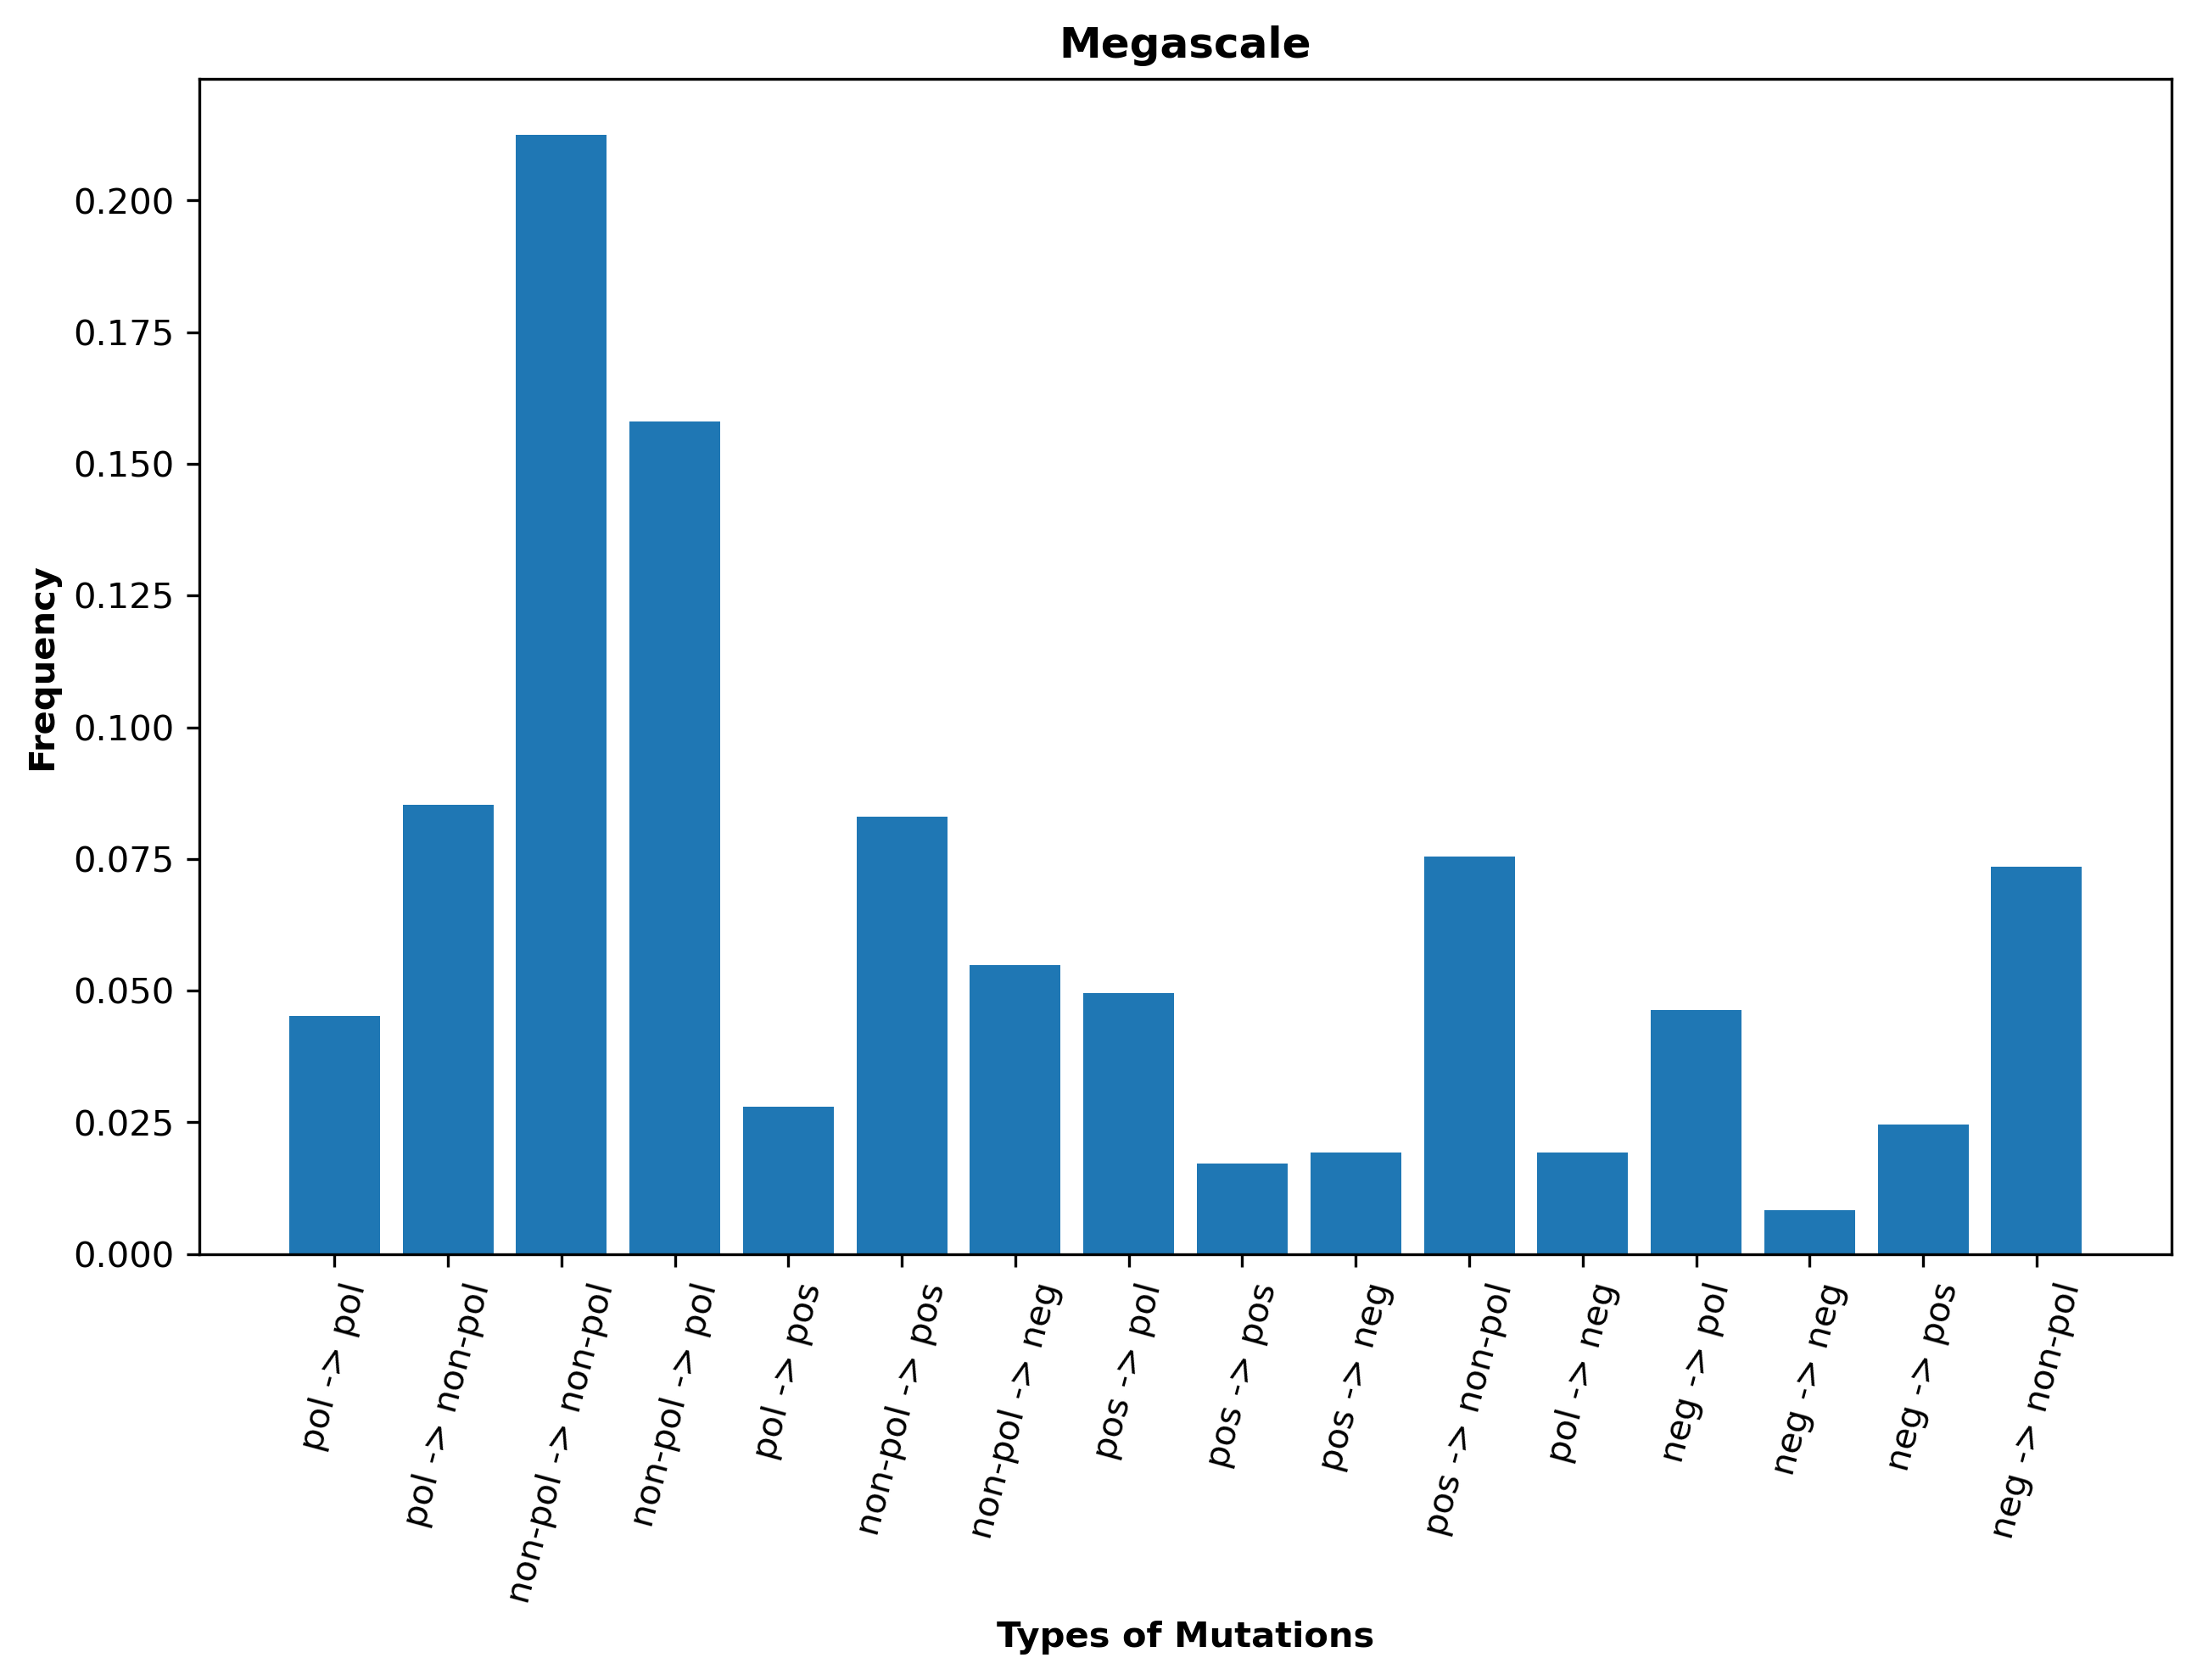

In [58]:
mega_mut_types = dict()

for data in correct_pred_dict['mega']:
    mutn = data[0]
    wt_aa = mutn[0]
    mut_aa = mutn[-1]
    transition = get_aa_type(wt_aa, aa_types) + " -> " + get_aa_type(mut_aa, aa_types)
    if transition not in mega_mut_types:
        mega_mut_types[transition] = 0
    mega_mut_types[transition] += 1

print(mega_mut_types)
plt.figure(figsize=(10, 6), dpi=300)
plt.bar(mega_mut_types.keys(), np.array(list(mega_mut_types.values()))/len(correct_pred_dict['mega']))
plt.xticks(rotation=75)
plt.xlabel('Types of Mutations', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Megascale', fontweight='bold')

{'non-pol -> neg': 3, 'non-pol -> non-pol': 111, 'neg -> non-pol': 8, 'non-pol -> pos': 7, 'pol -> pol': 10, 'pos -> pol': 10, 'pos -> non-pol': 12, 'neg -> pol': 2, 'non-pol -> pol': 23, 'pol -> non-pol': 39, 'pol -> neg': 2, 'neg -> pos': 5, 'pol -> pos': 2, 'pos -> pos': 2, 'neg -> neg': 1}


Text(0.5, 1.0, 'Fireprot')

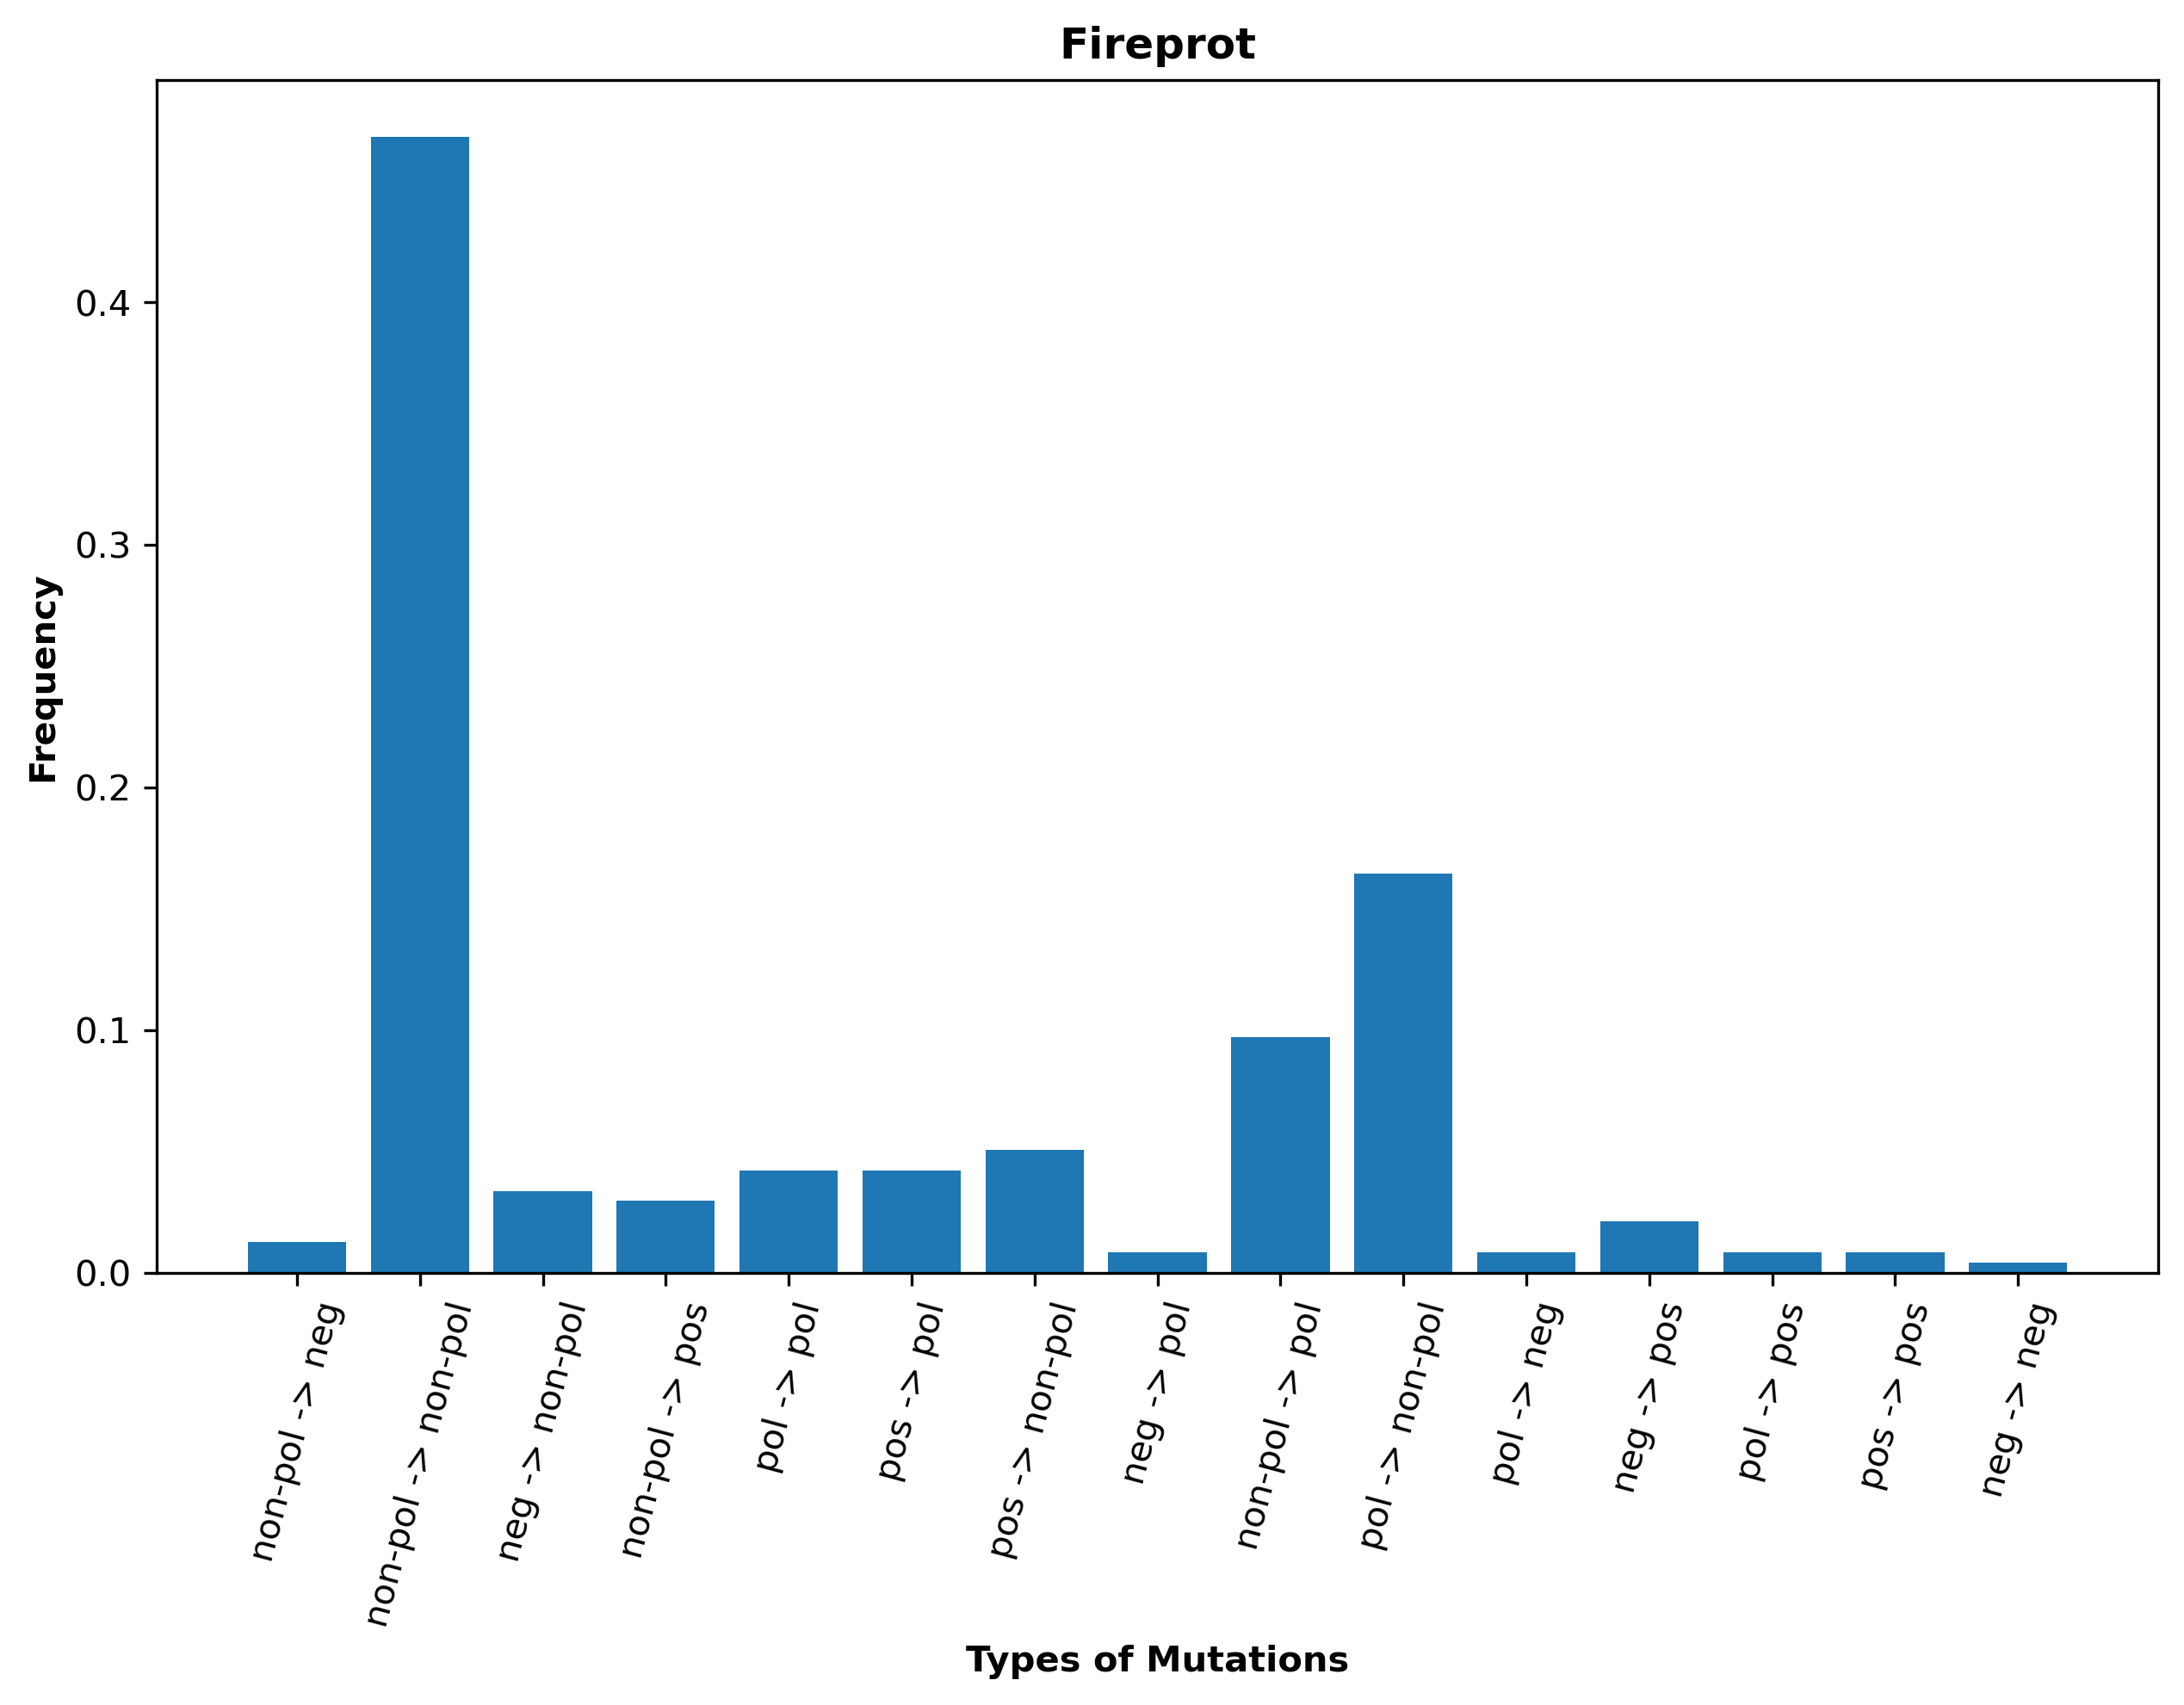

In [57]:
fire_mut_types = dict()

for data in correct_pred_dict['fire']:
    mutn = data[0]
    wt_aa = mutn[0]
    mut_aa = mutn[-1]
    transition = get_aa_type(wt_aa, aa_types) + " -> " + get_aa_type(mut_aa, aa_types)
    if transition not in fire_mut_types:
        fire_mut_types[transition] = 0
    fire_mut_types[transition] += 1

print(fire_mut_types)
plt.figure(figsize=(10, 6), dpi=300)
plt.bar(fire_mut_types.keys(), np.array(list(fire_mut_types.values()))/len(correct_pred_dict['fire']))
plt.xticks(rotation=75)
plt.xlabel('Types of Mutations', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Fireprot', fontweight='bold')

In [17]:
df_mega.head()

,protein_idx,pdb_name,mutation,pred_ddG,true_ddG,label
0,0,3DKM,N0Q,0.286392,0.029787,1
1,0,3DKM,N0E,0.291268,-0.322345,0
2,0,3DKM,N0H,0.189313,-0.265636,0
3,0,3DKM,N0D,0.227060,-0.294925,0
4,0,3DKM,N0T,0.132398,0.130931,1


{'pol -> pol': 1419, 'pol -> neg': 568, 'pol -> pos': 866, 'pol -> non-pol': 2611, 'non-pol -> pol': 4124, 'non-pol -> neg': 1303, 'non-pol -> pos': 2064, 'non-pol -> non-pol': 5625, 'pos -> pol': 1548, 'pos -> neg': 525, 'pos -> pos': 533, 'pos -> non-pol': 2345, 'neg -> pol': 1440, 'neg -> neg': 250, 'neg -> pos': 731, 'neg -> non-pol': 2220}


Text(0.5, 1.0, 'All megascale mutations')

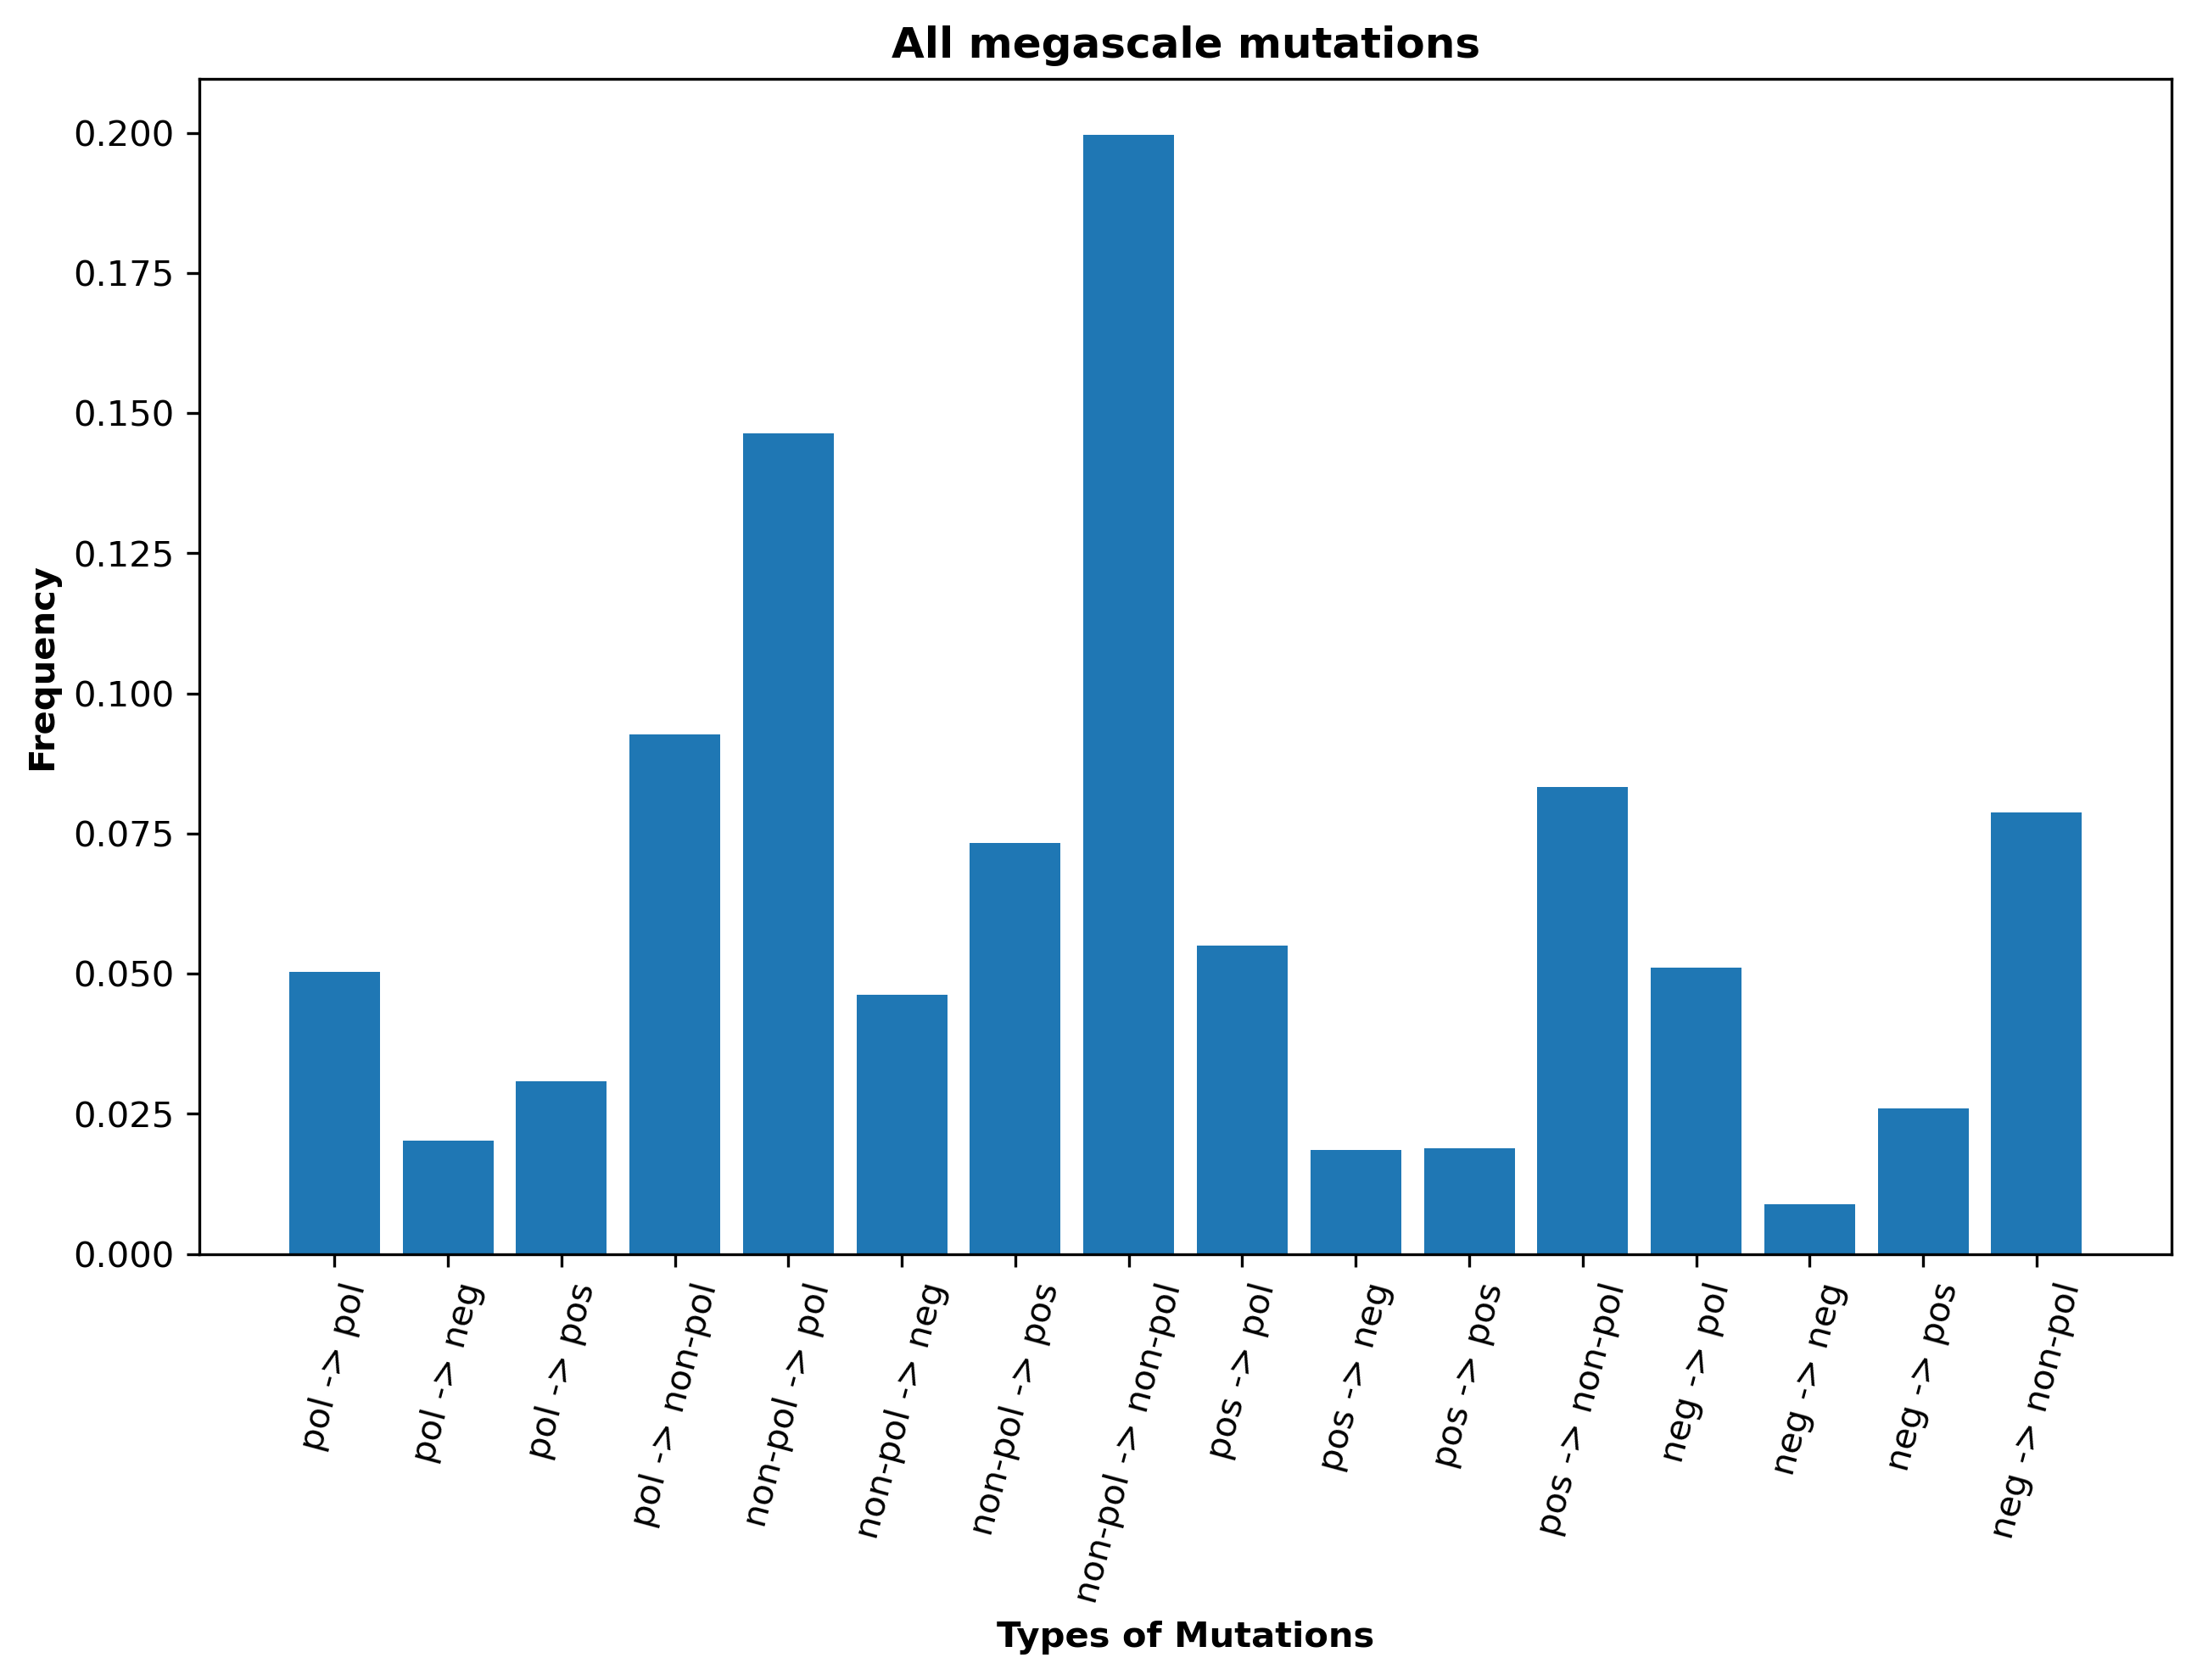

In [28]:
all_mega_mut_types = dict()

for mutn in df_mega['mutation']:
    wt_aa = mutn[0]
    mut_aa = mutn[-1]
    transition = get_aa_type(wt_aa, aa_types) + " -> " + get_aa_type(mut_aa, aa_types)
    if transition not in all_mega_mut_types:
        all_mega_mut_types[transition] = 0
    all_mega_mut_types[transition] += 1

print(all_mega_mut_types)
plt.figure(figsize=(10, 6), dpi=300)
plt.bar(all_mega_mut_types.keys(), np.array(list(all_mega_mut_types.values()))/len(df_mega))
plt.xticks(rotation=75)
plt.xlabel('Types of Mutations', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('All megascale mutations', fontweight='bold')

{'non-pol -> neg': 3, 'non-pol -> non-pol': 157, 'neg -> non-pol': 18, 'pol -> non-pol': 58, 'non-pol -> pos': 12, 'pol -> pol': 13, 'pos -> pol': 12, 'pos -> non-pol': 16, 'neg -> pol': 5, 'non-pol -> pol': 34, 'pol -> neg': 4, 'neg -> pos': 12, 'pol -> pos': 3, 'pos -> pos': 2, 'neg -> neg': 1}


Text(0.5, 1.0, 'All fireprot mutations')

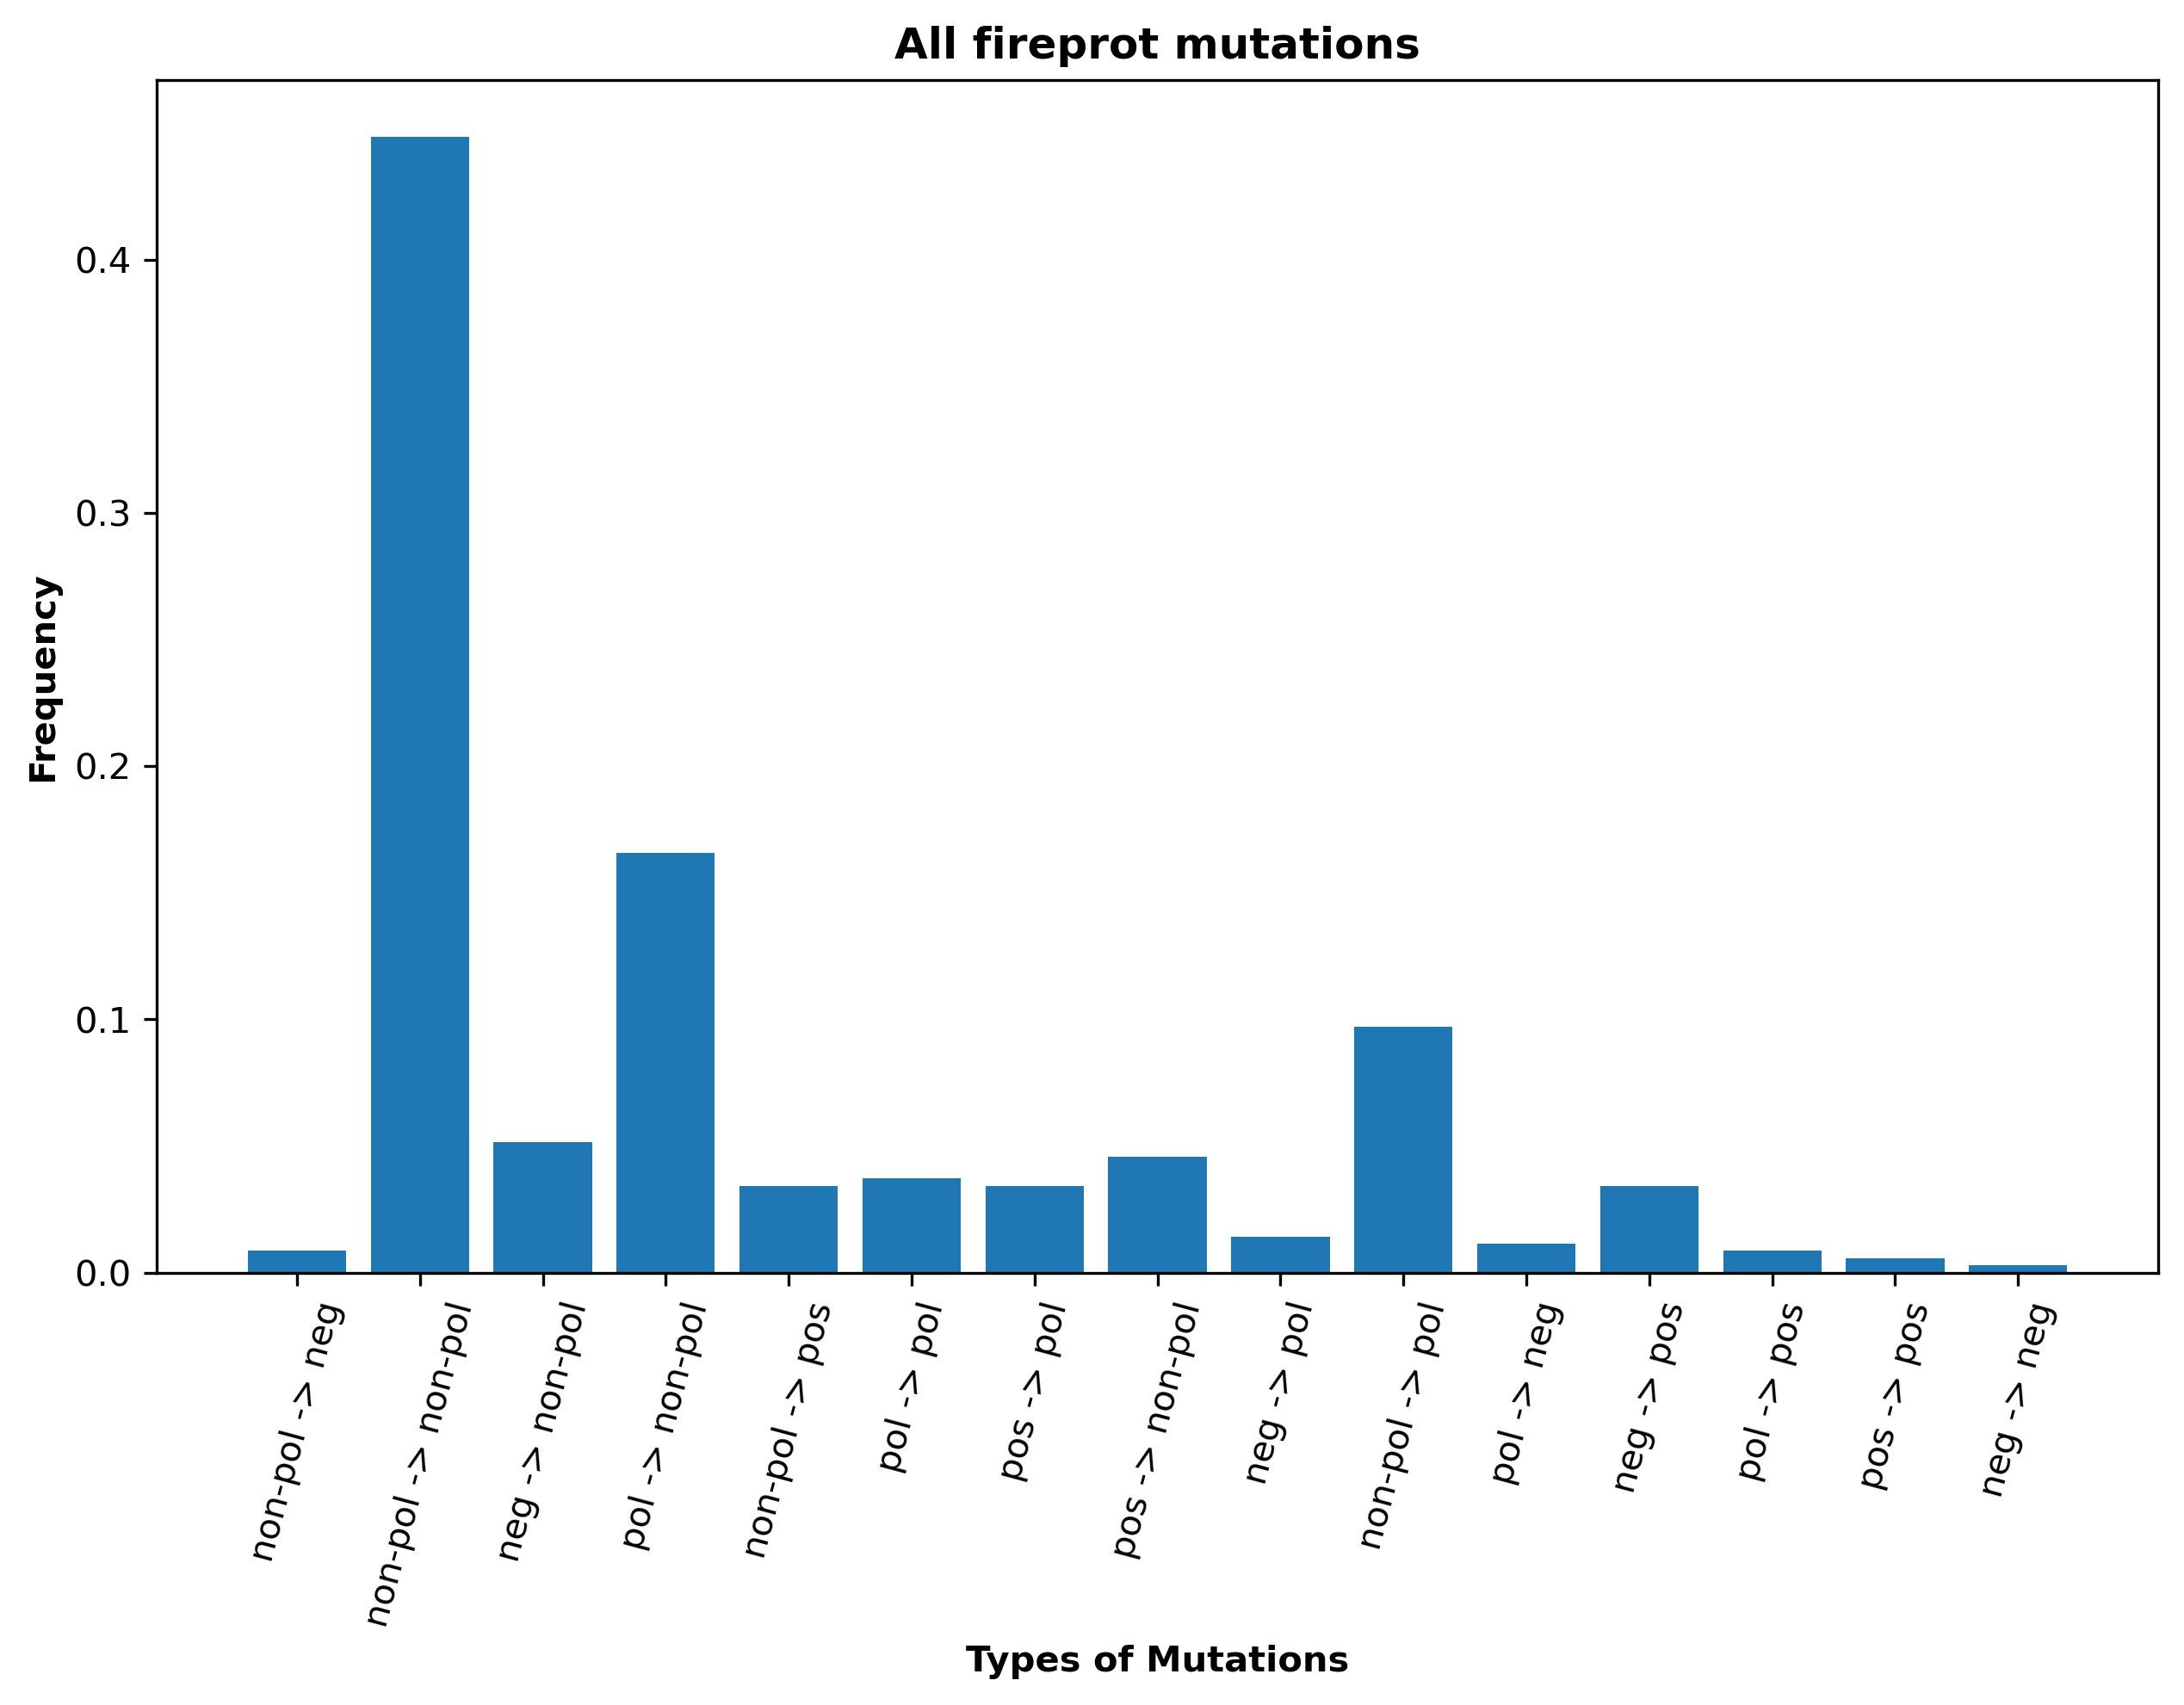

In [27]:
all_fire_mut_types = dict()

for mutn in df_fire['mutation']:
    wt_aa = mutn[0]
    mut_aa = mutn[-1]
    transition = get_aa_type(wt_aa, aa_types) + " -> " + get_aa_type(mut_aa, aa_types)
    if transition not in all_fire_mut_types:
        all_fire_mut_types[transition] = 0
    all_fire_mut_types[transition] += 1

print(all_fire_mut_types)
plt.figure(figsize=(10, 6), dpi=300)
plt.bar(all_fire_mut_types.keys(), np.array(list(all_fire_mut_types.values()))/len(df_fire))
plt.xticks(rotation=75)
plt.xlabel('Types of Mutations', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('All fireprot mutations', fontweight='bold')

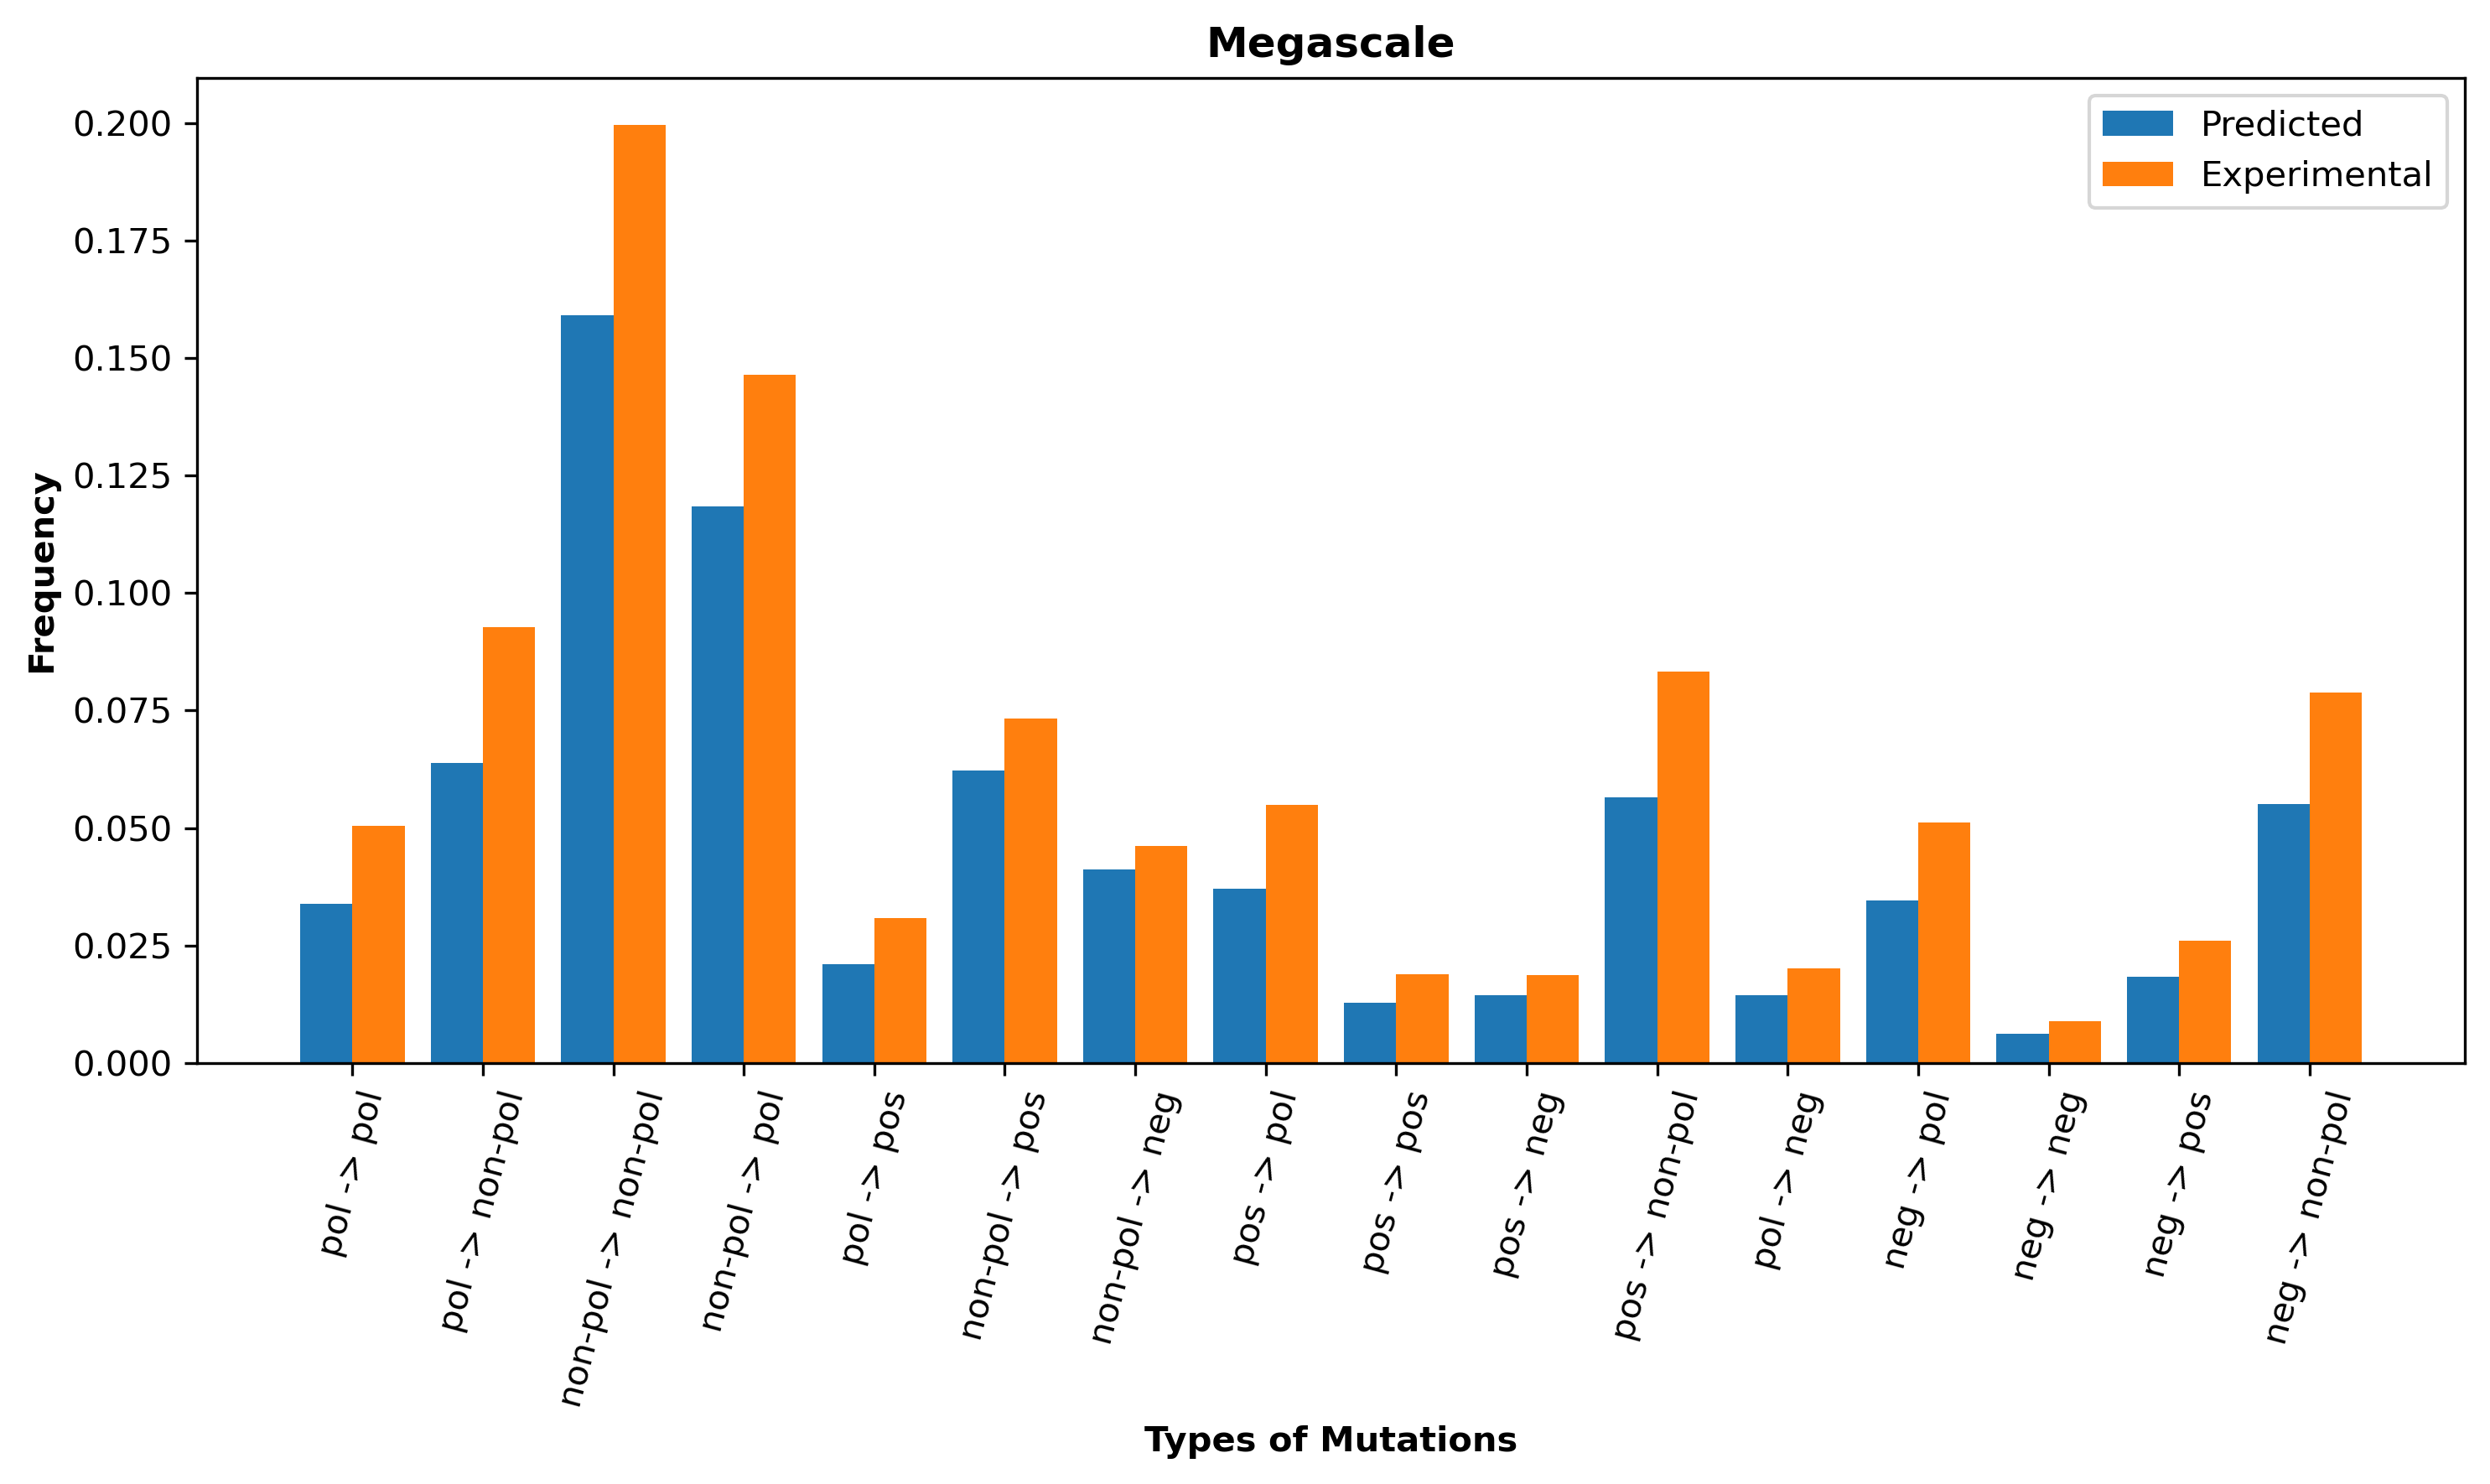

In [59]:
labels = list(dict.fromkeys(list(mega_mut_types.keys()) + list(all_mega_mut_types.keys())))
mega_counts = [mega_mut_types.get(label, 0) for label in labels]
all_mega_counts = [all_mega_mut_types.get(label, 0) for label in labels]

x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.bar(x - width / 2, np.array(mega_counts)/sum(all_mega_counts), width, label='Predicted')
ax.bar(x + width / 2, np.array(all_mega_counts)/sum(all_mega_counts), width, label='Experimental')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=75)
ax.set_xlabel('Types of Mutations', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Megascale', fontweight='bold')
ax.legend()
plt.tight_layout()

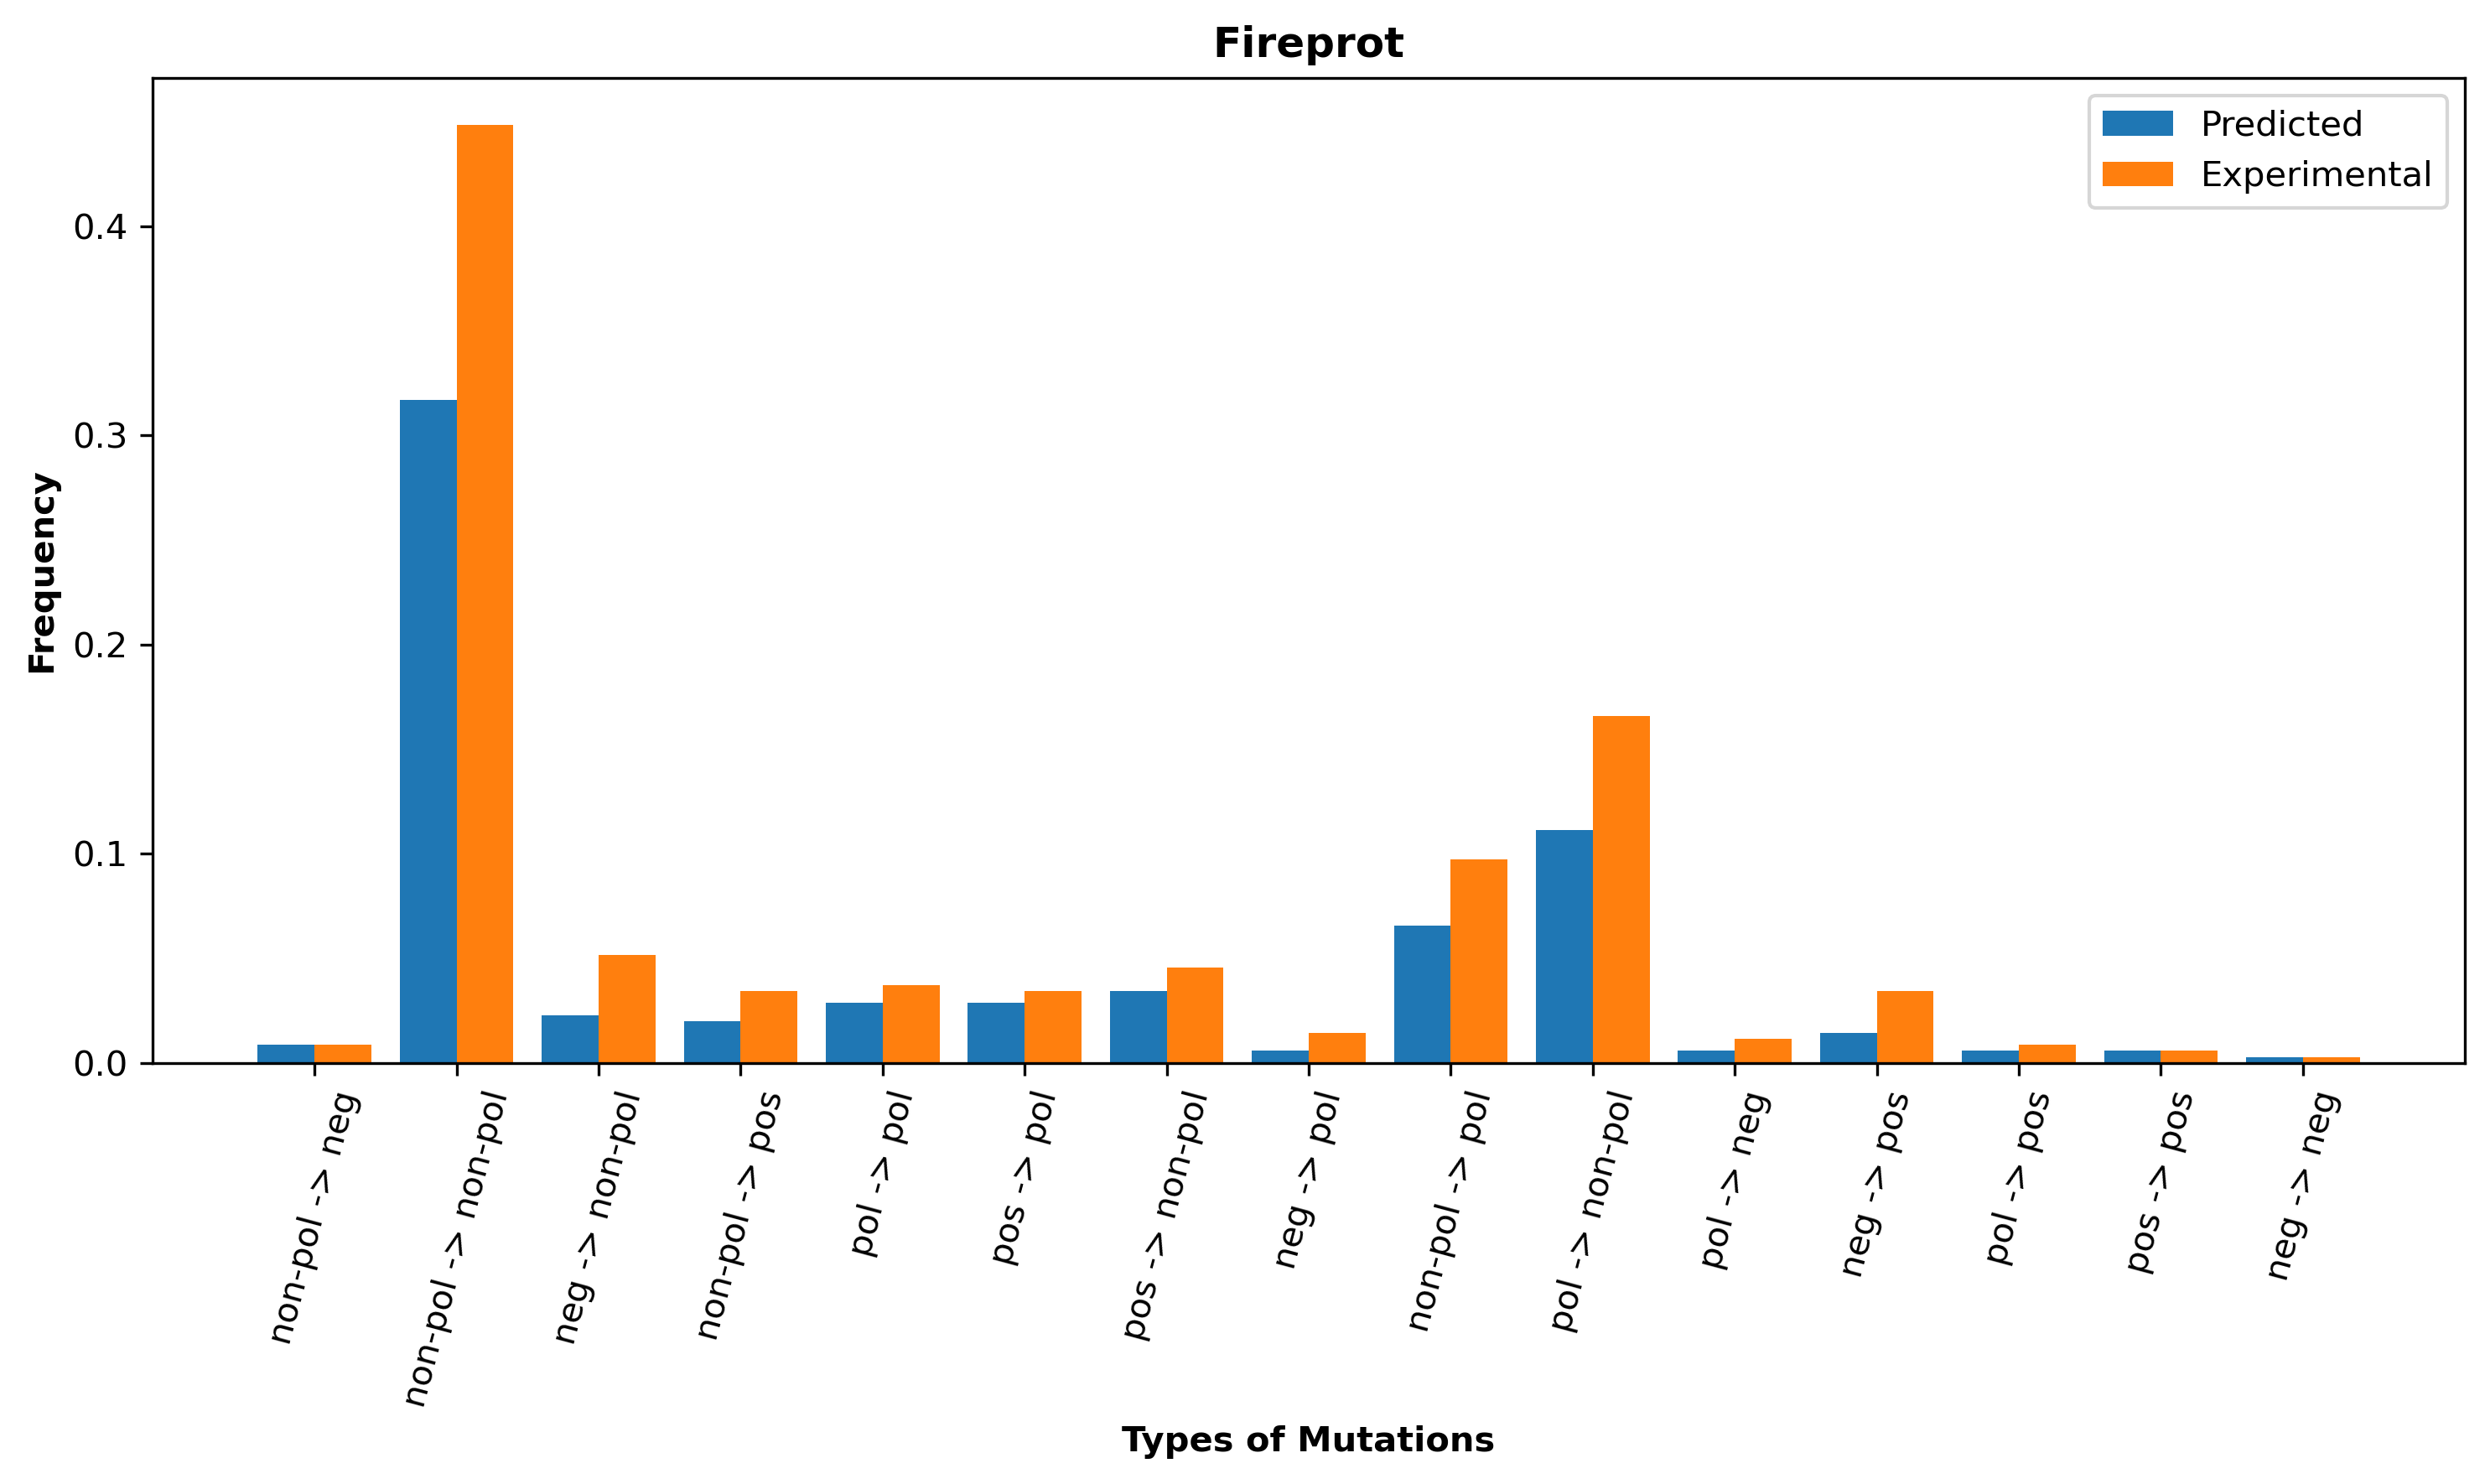

In [60]:
labels = list(dict.fromkeys(list(fire_mut_types.keys()) + list(all_fire_mut_types.keys())))
fire_counts = [fire_mut_types.get(label, 0) for label in labels]
all_fire_counts = [all_fire_mut_types.get(label, 0) for label in labels]

x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.bar(x - width / 2, np.array(fire_counts)/sum(all_fire_counts), width, label='Predicted')
ax.bar(x + width / 2, np.array(all_fire_counts)/sum(all_fire_counts), width, label='Experimental')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=75)
ax.set_xlabel('Types of Mutations', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Fireprot', fontweight='bold')
ax.legend()
plt.tight_layout()

In [52]:
wrong_pred_dict = {
    "mega": list(
        df_mega.loc[
            (df_mega["label"] == 0),
            ["mutation", "pred_ddG"]
        ].itertuples(index=False, name=None)
    ),
    "fire": list(
        df_fire.loc[
            (df_fire["label"] == 0),
            ["mutation", "pred_ddG"]
        ].itertuples(index=False, name=None)
    )
}

{'pol -> neg': 160, 'pol -> pos': 276, 'pol -> non-pol': 813, 'non-pol -> pol': 789, 'non-pol -> neg': 144, 'non-pol -> pos': 312, 'non-pol -> non-pol': 1141, 'pol -> pol': 467, 'pos -> neg': 119, 'pos -> pol': 503, 'pos -> non-pol': 754, 'pos -> pos': 172, 'neg -> pol': 464, 'neg -> pos': 213, 'neg -> non-pol': 669, 'neg -> neg': 74}


Text(0.5, 1.0, 'Megascale (Wrong Predictions)')

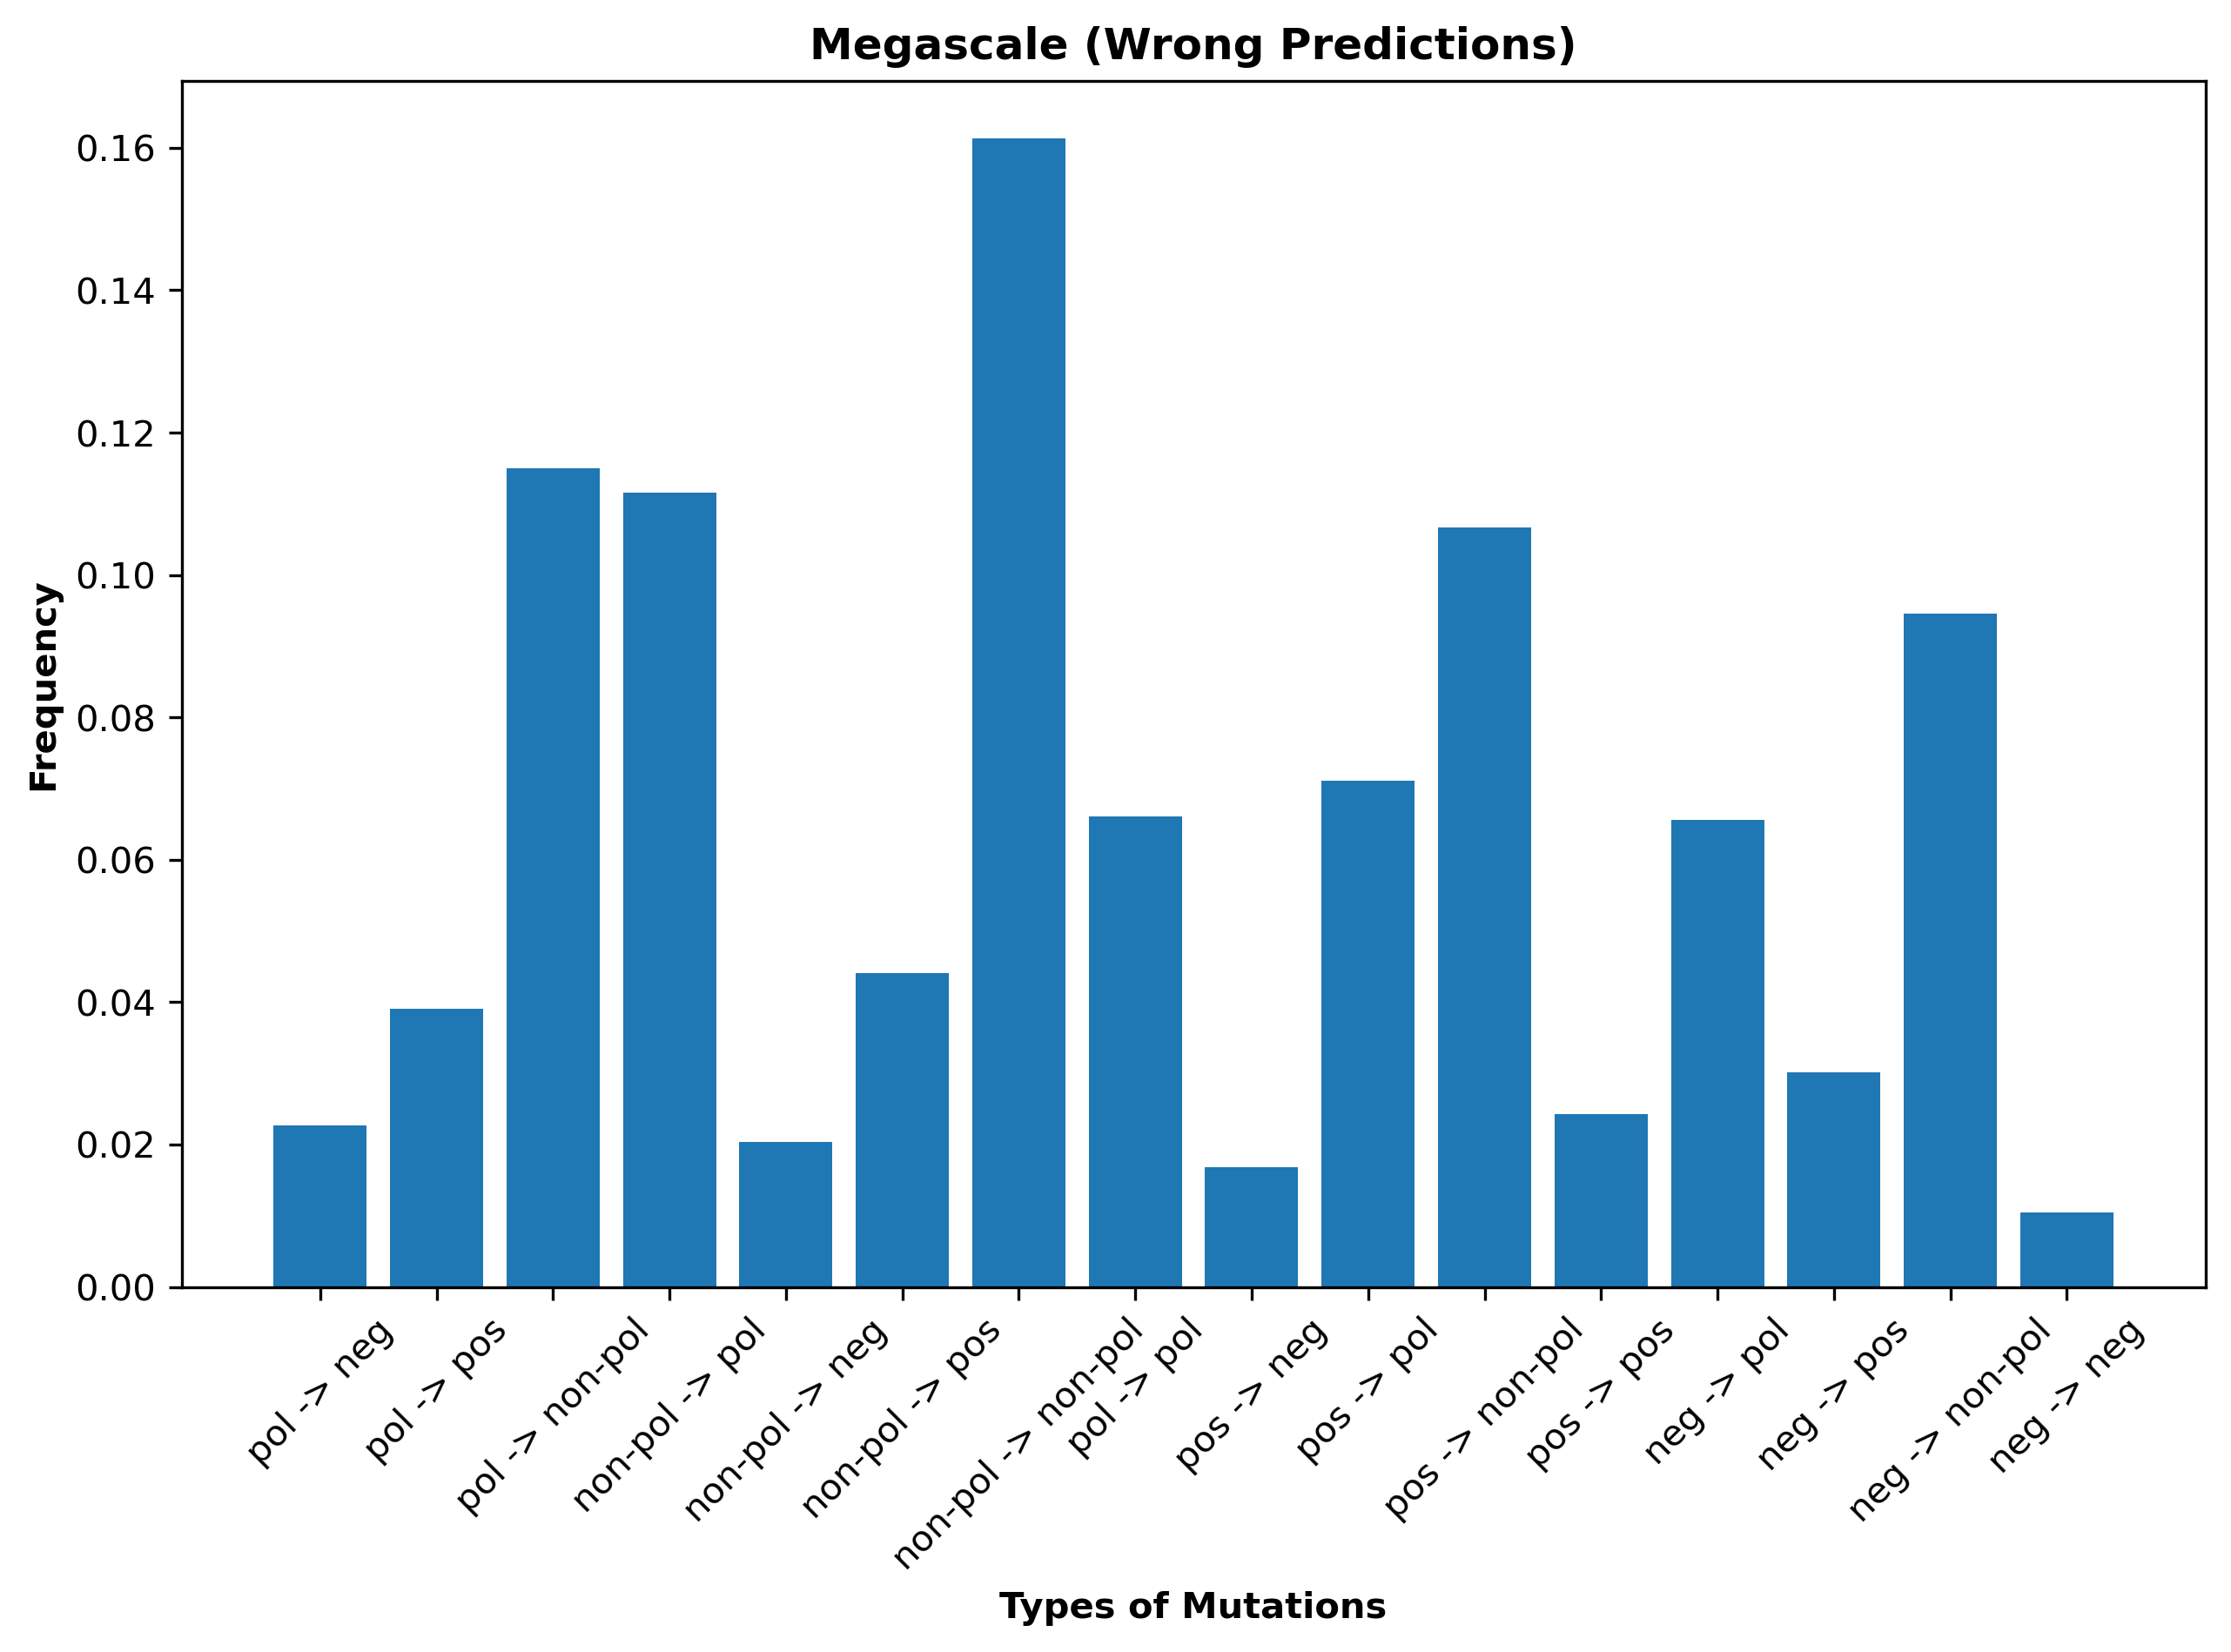

In [53]:
mega_mut_types = dict()

for data in wrong_pred_dict['mega']:
    mutn = data[0]
    wt_aa = mutn[0]
    mut_aa = mutn[-1]
    transition = get_aa_type(wt_aa, aa_types) + " -> " + get_aa_type(mut_aa, aa_types)
    if transition not in mega_mut_types:
        mega_mut_types[transition] = 0
    mega_mut_types[transition] += 1

print(mega_mut_types)
plt.figure(figsize=(10, 6), dpi=300)
plt.bar(mega_mut_types.keys(), np.array(list(mega_mut_types.values()))/len(wrong_pred_dict['mega']))
plt.xticks(rotation=45)
plt.xlabel('Types of Mutations', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Megascale (Wrong Predictions)', fontweight='bold')

{'non-pol -> non-pol': 46, 'pol -> non-pol': 19, 'pos -> non-pol': 4, 'neg -> non-pol': 10, 'non-pol -> pol': 11, 'pos -> pol': 2, 'pol -> neg': 2, 'pol -> pos': 1, 'pol -> pol': 3, 'non-pol -> pos': 5, 'neg -> pos': 7, 'neg -> pol': 3}


Text(0.5, 1.0, 'Fireprot (Wrong Predictions)')

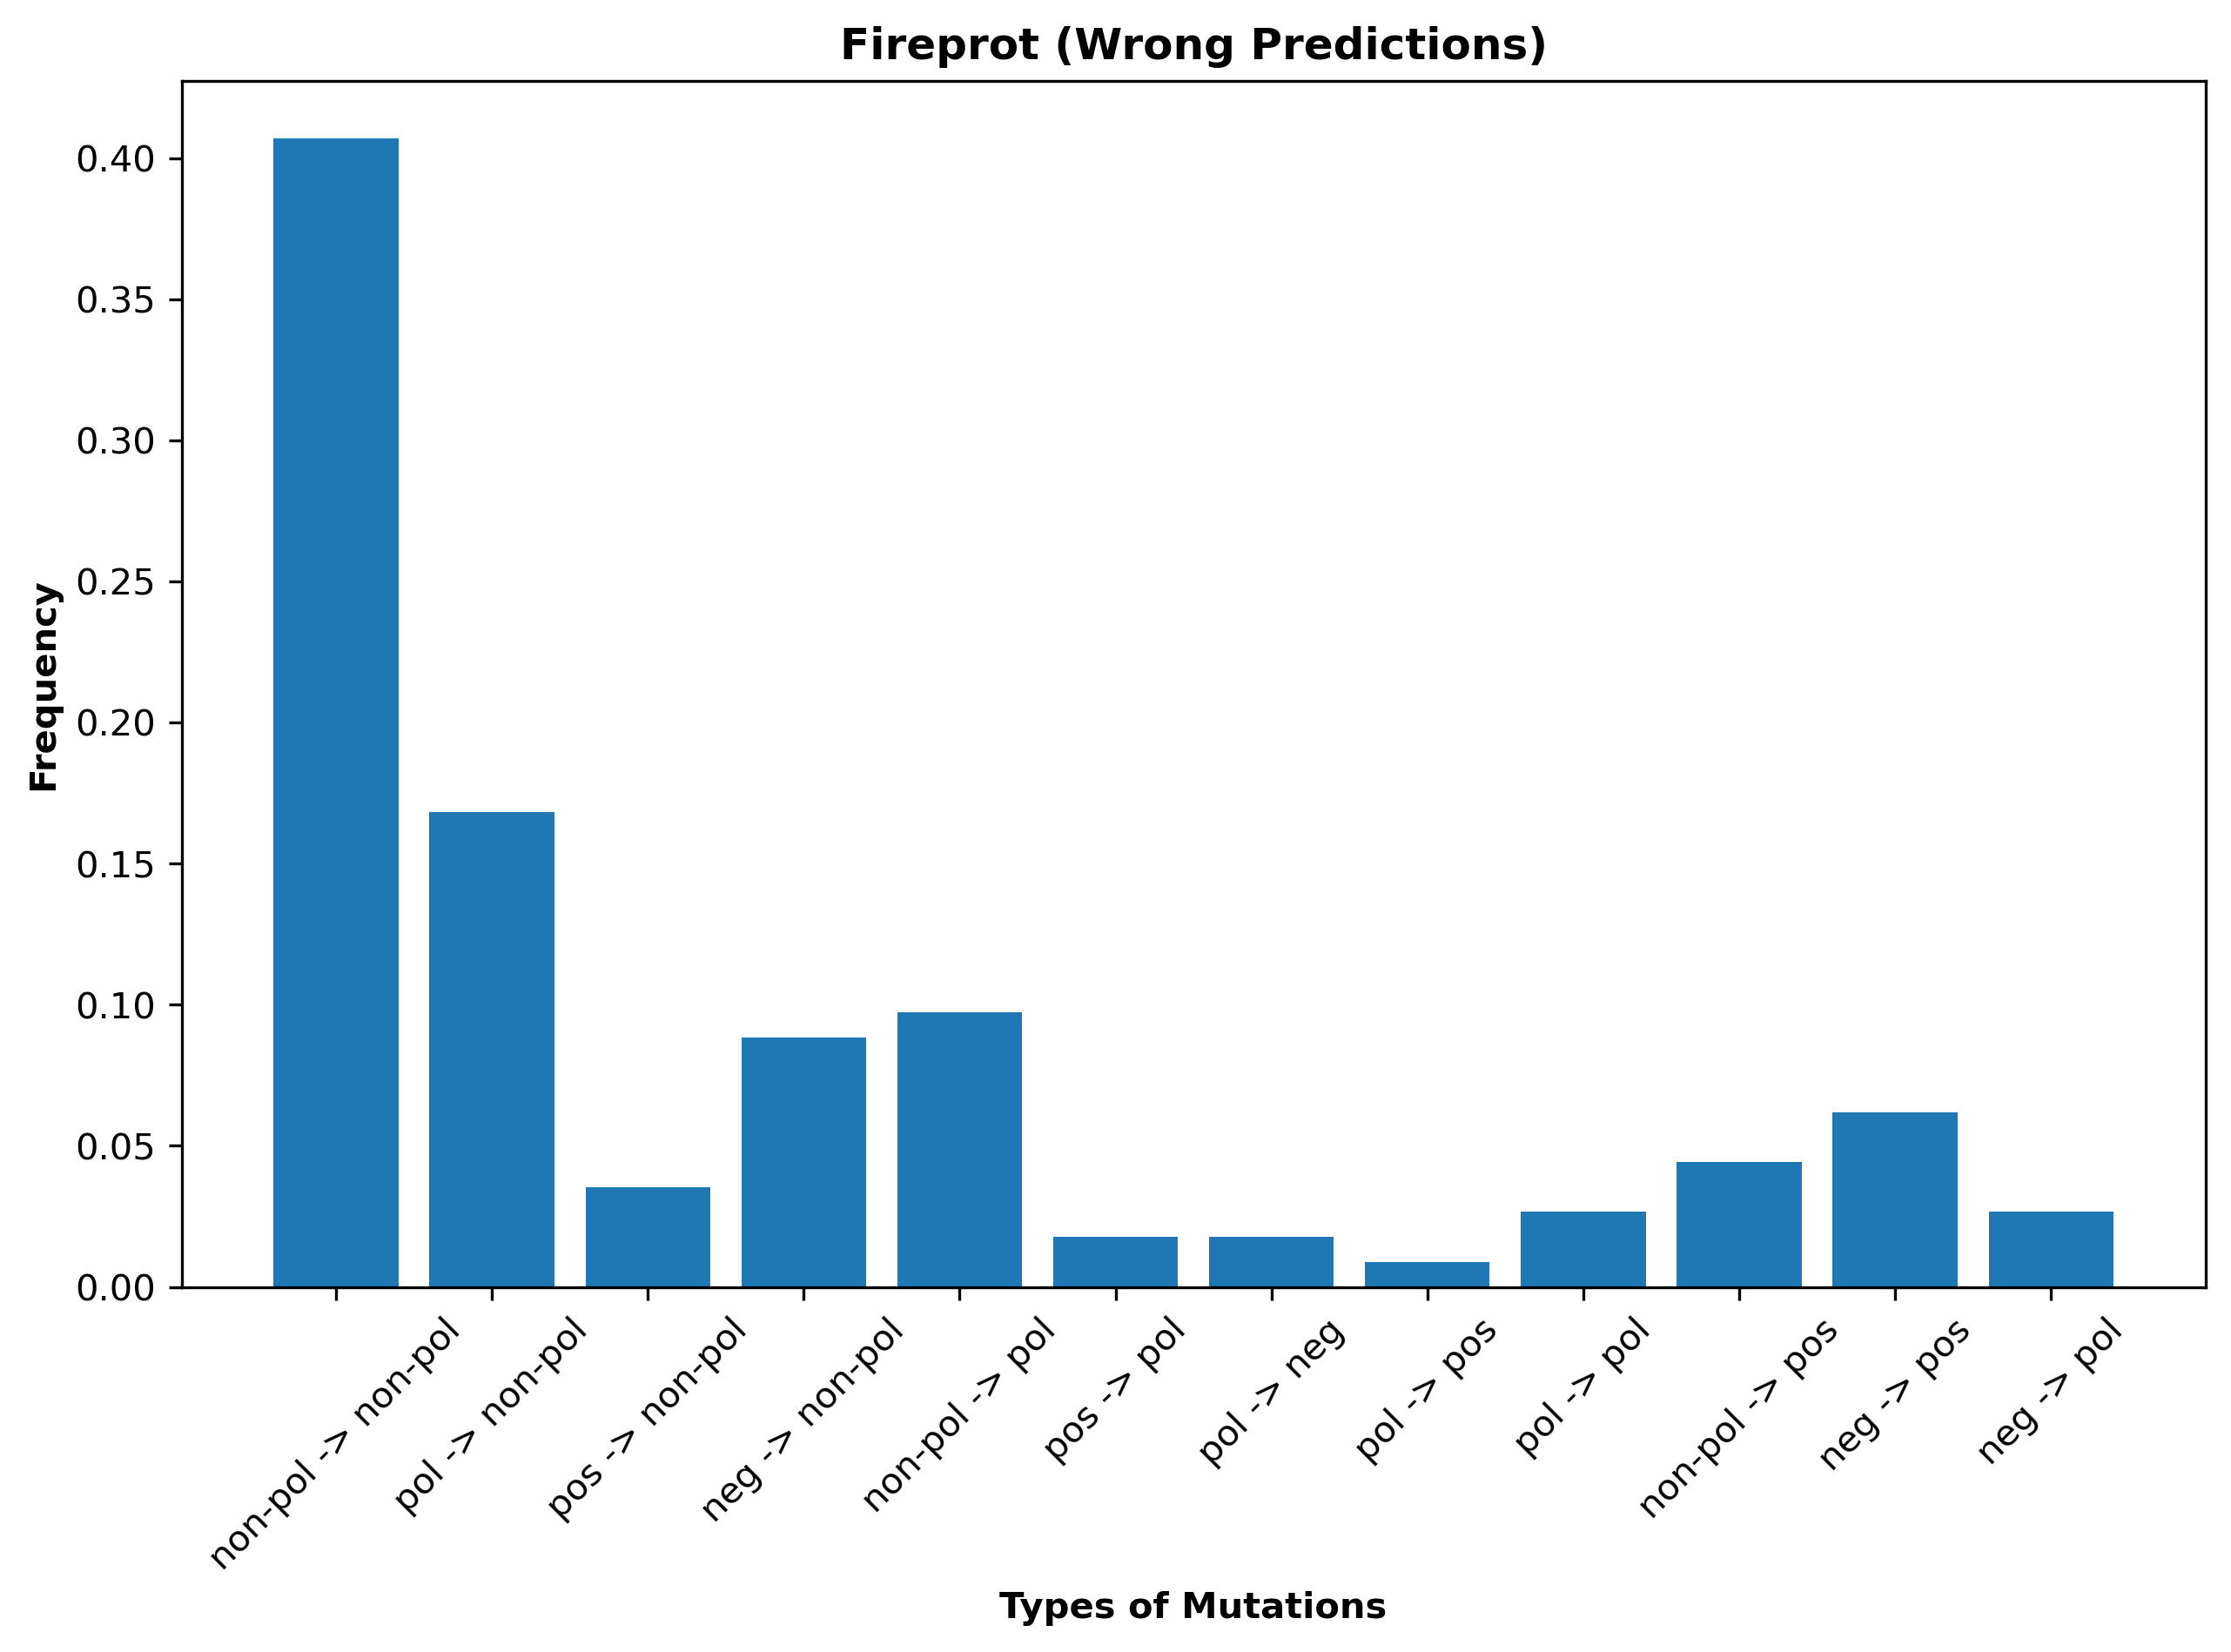

In [55]:
fire_mut_types = dict()

for data in wrong_pred_dict['fire']:
    mutn = data[0]
    wt_aa = mutn[0]
    mut_aa = mutn[-1]
    transition = get_aa_type(wt_aa, aa_types) + " -> " + get_aa_type(mut_aa, aa_types)
    if transition not in fire_mut_types:
        fire_mut_types[transition] = 0
    fire_mut_types[transition] += 1

print(fire_mut_types)
plt.figure(figsize=(10, 6), dpi=300)
plt.bar(fire_mut_types.keys(), np.array(list(fire_mut_types.values()))/len(wrong_pred_dict['fire']))
plt.xticks(rotation=45)
plt.xlabel('Types of Mutations', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Fireprot (Wrong Predictions)', fontweight='bold')

{'pol -> non-pol': 4, 'pol -> neg': 2, 'pos -> pos': 5, 'pos -> non-pol': 4, 'neg -> non-pol': 1, 'non-pol -> non-pol': 8, 'non-pol -> neg': 3, 'non-pol -> pos': 2, 'pol -> pol': 2, 'pos -> pol': 3, 'pos -> neg': 1, 'non-pol -> pol': 2, 'neg -> pol': 1}


Text(0.5, 1.0, 'All stabilising mutations')

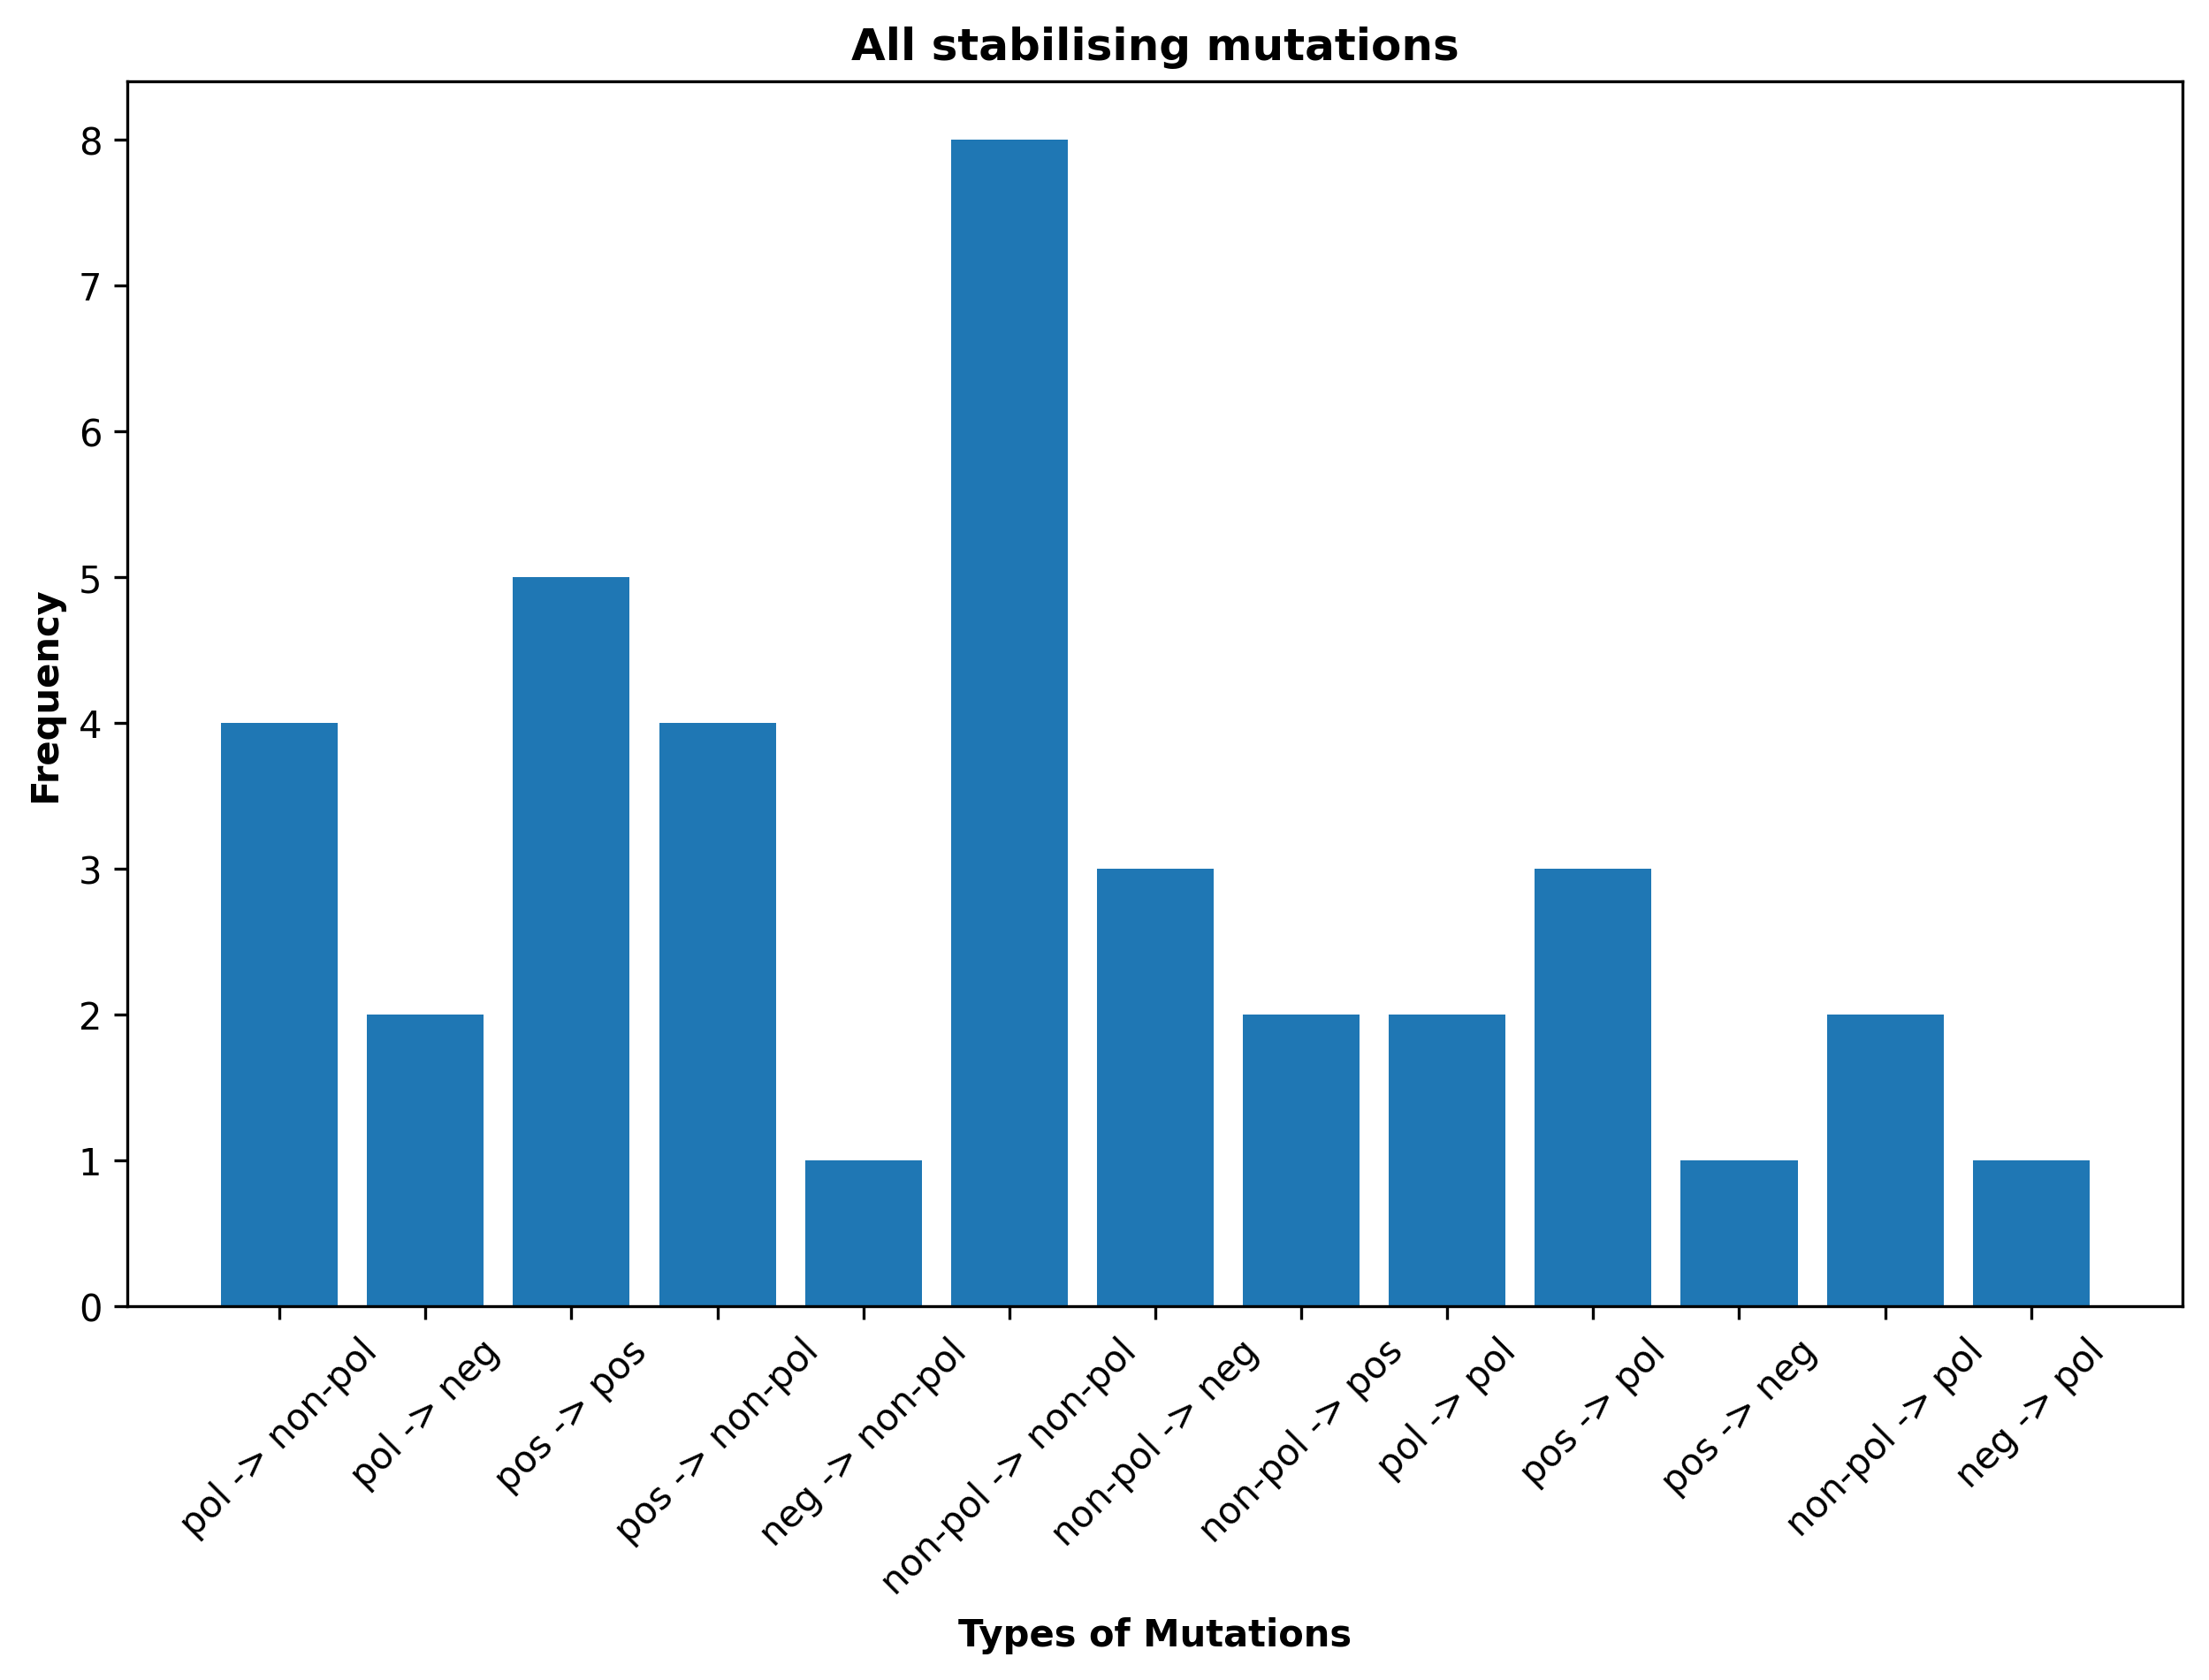

In [29]:
all_stab_mut_types = dict()

for mutn, dTm in RV_df.itertuples(index=False, name=None):
    if dTm > 0:  # Consider only stabilizing mutations
        wt_aa = mutn[0]
        mut_aa = mutn[-1]
        transition = get_aa_type(wt_aa, aa_types) + " -> " + get_aa_type(mut_aa, aa_types)
        if transition not in all_stab_mut_types:
            all_stab_mut_types[transition] = 0
        all_stab_mut_types[transition] += 1

print(all_stab_mut_types)
plt.figure(figsize=(10, 6), dpi=300)
plt.bar(all_stab_mut_types.keys(), all_stab_mut_types.values())
plt.xticks(rotation=45)
plt.xlabel('Types of Mutations', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('All stabilising mutations', fontweight='bold')

### Computing classification metrics on CCdB data

In [5]:
import pandas as pd

CcdB_data = pd.read_excel("/home/user/Documents/ProteinMPNN/ddg_pipeline/supp_info-ddG-MFI.xlsx")
CcdB_Tm = CcdB_data['dTm'].values
# athi_data = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/athi-data/filtered_athi-data.csv")
# CcdB_Tm = athi_data['delta_Tm_K'].values
s571_data = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/Model_S571_raw_preds.csv")
s571_Tm = s571_data['True values'].values
predictions = s571_data['ddG_pred'].values
# predictions = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/Model_S571_raw_preds.csv")
# print(predictions.head())

# Ensure same number of samples
# print(f"CcdB samples: {len(CcdB_Tm)}")
print(f"Prediction samples: {len(predictions)}")
print(f"s571 samples: {len(s571_Tm)}")
# assert len(CcdB_Tm) == len(predictions), "Mismatch in sample count"

Prediction samples: 389
s571 samples: 389


R-squared: 0.069
R-value: -0.262


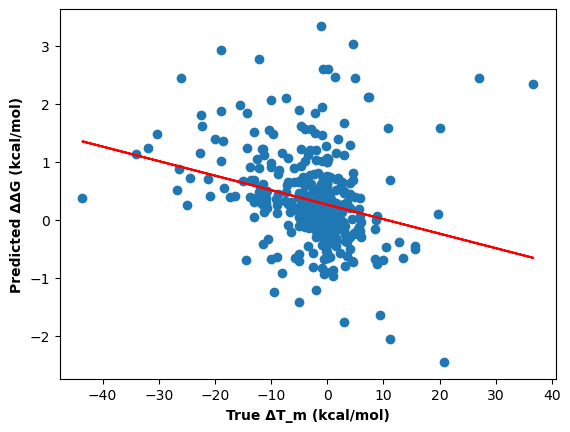

In [26]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

m, c, r_value, p_value, std_err = linregress(s571_Tm, predictions)
plt.scatter(s571_Tm, predictions)
plt.plot(s571_Tm, m * s571_Tm + c, color='red', linestyle='-')
plt.xlabel('True ΔT_m (kcal/mol)', fontweight='bold')
plt.ylabel('Predicted ΔΔG (kcal/mol)', fontweight='bold')
print(f"R-squared: {r_value**2:.3f}")
print(f"R-value: {r_value:.3f}")

In [34]:
data = pd.read_csv("/home/user/Documents/ProteinMPNN/datasets/filtered_ssym_inv.csv")
print(data.shape)
# print(data.head())
count_0 = (data['DDG'] == 0).sum()
print(f"Number of mutations with DDG = 0: {count_0}")

(342, 6)
Number of mutations with DDG = 0: 4


#### Regression model test on CcdB

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, matthews_corrcoef, confusion_matrix, classification_report

# Create binary labels from dTm: stable (dTm > 0) = 1, unstable (dTm <= 0) = 0
y_true_binary = (s571_Tm > 0).astype(int)
y_pred_binary = (predictions < 0).astype(int)

# Compute metrics
accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
mcc = matthews_corrcoef(y_true_binary, y_pred_binary)

cm = confusion_matrix(y_true_binary, y_pred_binary)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"MCC:       {mcc:.3f}")

print(f"                    Predicted Stable  Predicted Unstable")
print(f"True Stable (dTm>0)         {cm[1, 1]:<18} {cm[1, 0]}")
print(f"True Unstable (dTm<=0)      {cm[0, 1]:<18} {cm[0, 0]}")

Accuracy:  0.656
Precision: 0.480
Recall:    0.457
MCC:       0.214
                    Predicted Stable  Predicted Unstable
True Stable (dTm>0)         59                 70
True Unstable (dTm<=0)      64                 196


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, matthews_corrcoef, confusion_matrix, classification_report

# Create binary labels from dTm: stable (dTm > 0) = 1, unstable (dTm <= 0) = 0
y_true_binary = (CcdB_Tm > 0).astype(int)

# Extract predicted class from predictions
# For binary, stable (-1) -> 1, neutral/unstable (0 or 1) -> 0
y_pred_binary = (predictions['predicted_class'].values == -1).astype(int)

# Compute metrics
accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
mcc = matthews_corrcoef(y_true_binary, y_pred_binary)

# Confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)

print("="*70)
print("Classification Metrics on CcdB Data (Positive Class: Stable)")
print("="*70)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"MCC:       {mcc:.4f}")
print("\n" + "="*70)
print("Confusion Matrix (True x Predicted)")
print("Positive class: Stable (dTm > 0)")
print("="*70)
# Reorder to show Stable (positive class) first
print(f"                    Predicted Stable  Predicted Unstable")
print(f"True Stable (dTm>0)         {cm[1, 1]:<18} {cm[1, 0]}")
print(f"True Unstable (dTm<=0)      {cm[0, 1]:<18} {cm[0, 0]}")
print("\n" + "="*70)
print("Classification Report:")
print("="*70)
print(classification_report(y_true_binary, y_pred_binary, 
                          target_names=['Unstable (dTm <= 0)', 'Stable (dTm > 0)'],
                          zero_division=0))

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/pred-results/mymodel3.13-oligomer.csv")
print(data.shape)
data.head(-1)

(1919, 8)


,pdb,chain_id,position,wildtype,mutation,mutation_str,predicted_ddG_normalized,predicted_ddG_denormalized
0,3vub_dimer_mod,Homo,0,M,A,M0A,0.605297,0.802648
1,3vub_dimer_mod,Homo,0,M,C,M0C,1.751373,1.375686
2,3vub_dimer_mod,Homo,0,M,D,M0D,0.979503,0.989751
3,3vub_dimer_mod,Homo,0,M,E,M0E,1.005344,1.002672
4,3vub_dimer_mod,Homo,0,M,F,M0F,1.164538,1.082269
...,...,...,...,...,...,...,...,...
1913,3vub_dimer_mod,Homo,100,I,R,I100R,0.992557,0.996278
1914,3vub_dimer_mod,Homo,100,I,S,I100S,1.054327,1.027164
1915,3vub_dimer_mod,Homo,100,I,T,I100T,0.917967,0.958983
1916,3vub_dimer_mod,Homo,100,I,V,I100V,0.681529,0.840765


(1919,)


Text(0.5, 1.0, 'Distribution of Predicted ΔΔG for 2SOD Mutations')

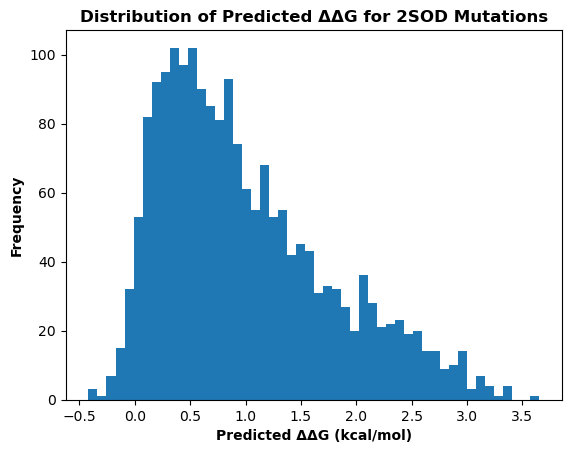

In [6]:
ddg = data['predicted_ddG_normalized'].values
print(ddg.shape)
plt.hist(ddg, bins=50)
plt.xlabel('Predicted ΔΔG (kcal/mol)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Predicted ΔΔG for 2SOD Mutations', fontweight='bold')

In [7]:
stable_count = np.sum(ddg < 0)
unstable_count = np.sum(ddg >= 0)
print(f"Predicted Stable Mutations (ΔΔG < 0): {(stable_count/len(ddg)*100):.3f}%")
print(f"Predicted Unstable Mutations (ΔΔG >= 0): {(unstable_count/len(ddg)*100):.3f}%")

Predicted Stable Mutations (ΔΔG < 0): 3.283%
Predicted Unstable Mutations (ΔΔG >= 0): 96.717%


### SKEMPI2 data

In [84]:
from pathlib import Path
import os

In [79]:
skempi_data = pd.read_csv("/home/user/Documents/ProteinMPNN/datasets/SKEMPI2_filtered_final.csv") # ProtBFF CSV 
print(skempi_data.shape)
unique_pdbs = skempi_data['#Pdb_origin'].nunique()
print(f"Number of unique PDB entries: {unique_pdbs}")
pdb_names = skempi_data['#Pdb_origin'].unique()
skempi_data.head()

(6660, 7)
Number of unique PDB entries: 339


,#Pdb,#Pdb_origin,Partner1,Partner2,Mutation(s)_cleaned,ddG,Label
0,0_1CSE,1CSE,E,I,LI38G,2.280577,forward
1,1_1CSE,1CSE,E,I,LI38S,1.188776,forward
2,2_1CSE,1CSE,E,I,LI38P,6.765446,forward
3,3_1CSE,1CSE,E,I,LI38I,2.982502,forward
4,4_1CSE,1CSE,E,I,LI38D,4.411843,forward


In [75]:
## From the original SKEMPI2 dataset ##
og_pdb_dir = Path("/media/user/DATA/raghav/Documents/ProteinMPNN/SKEMPI2/SKEMPI2_PDBs/PDBs/")
clean_pdb_names = []
count = 0
for pdb_file in og_pdb_dir.glob("*.pdb"):
    if pdb_file.suffix == ".pdb" and not pdb_file.name.startswith("._"):
        count += 1
        clean_pdb_names.append(pdb_file.name)
print(count)
print(clean_pdb_names[:5])

345
['1B3S.pdb', '2G2U.pdb', '3M63.pdb', '3N0P.pdb', '4HSA.pdb']


Cleaning and copying all the valid SKEMPI2 PDBs into a directory

In [87]:
final_pdb_dir = "/media/user/DATA/raghav/Documents/ProteinMPNN/SKEMPI2/filtered_PDBs/"
os.makedirs(final_pdb_dir, exist_ok=True)
base_dir = "/media/user/DATA/raghav/Documents/ProteinMPNN/SKEMPI2/SKEMPI2_PDBs/PDBs/"
c = 0
for pdb in pdb_names:
    pdb_file = base_dir + pdb + ".pdb"
    if os.path.exists(pdb_file):
        os.system(f"cp {pdb_file} {final_pdb_dir}")
        c += 1
print(f"Copied {c} PDB files to {final_pdb_dir}")

Copied 339 PDB files to /media/user/DATA/raghav/Documents/ProteinMPNN/SKEMPI2/filtered_PDBs/


#### Classification analyses

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, matthews_corrcoef, confusion_matrix, classification_report
import pandas as pd

def compute_class_metrics(y_true_binary, y_pred_binary):
    accuracy = accuracy_score(y_true_binary, y_pred_binary)
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    mcc = matthews_corrcoef(y_true_binary, y_pred_binary)

    cm = confusion_matrix(y_true_binary, y_pred_binary)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"MCC:       {mcc:.4f}")
    print("\nConfusion Matrix:")
    print(f"                    Predicted Stable  Predicted Unstable")
    print(f"True Stable (dTm>0)         {cm[1, 1]:<18} {cm[1, 0]}")
    print(f"True Unstable (dTm<=0)      {cm[0, 1]:<18} {cm[0, 0]}")

In [6]:
## CcdB dataset ##
CcdB_data = pd.read_excel("/home/user/Documents/ProteinMPNN/ddg_pipeline/supp_info-ddG-MFI.xlsx")
# CcdB_data.head()
dTm = CcdB_data['dTm'].values
preds = pd.read_csv("pred-results/model3.21.6-MLP-FT-results103.csv")['predicted_ddG_normalized'].values
# preds.head()
y_true_binary = (dTm > 0).astype(int)
y_pred_binary = (preds < 0).astype(int)
compute_class_metrics(y_true_binary, y_pred_binary)

Accuracy:  0.6585
Precision: 0.8571
Recall:    0.3158
MCC:       0.3583

Confusion Matrix:
                    Predicted Stable  Predicted Unstable
True Stable (dTm>0)         12                 26
True Unstable (dTm<=0)      2                  42


In [29]:
## SKEMPI2 dataset ##
skempi_data = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/test-results/mymodel3.21.6_skempi.csv")
skempi_data.head()
true = skempi_data['true_ddG'].values
preds = skempi_data['pred_ddG_normalized'].values
y_true_binary = (true < 0).astype(int)
y_pred_binary = (preds < 0).astype(int)
compute_class_metrics(y_true_binary, y_pred_binary)

Accuracy:  0.5449
Precision: 0.2479
Recall:    0.3295
MCC:       -0.0416

Confusion Matrix:
                    Predicted Stable  Predicted Unstable
True Stable (dTm>0)         29                 59
True Unstable (dTm<=0)      88                 147


In [32]:
## Megascale & Fireprot datasets ##
mega_data = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/test-results/ablation-esm_megascale.csv")
fire_data = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/test-results/ablation-esm_fireprot.csv")
true_mega = mega_data['true_ddG'].values
preds_mega = mega_data['pred_ddG_normalized'].values
y_true_binary_mega = (true_mega < 0).astype(int)
y_pred_binary_mega = (preds_mega < 0).astype(int)
print('Megascale')
compute_class_metrics(y_true_binary_mega, y_pred_binary_mega)
print('\n')

true_fire = fire_data['true_ddG'].values
preds_fire = fire_data['pred_ddG_normalized'].values
y_true_binary_fire = (true_fire < 0).astype(int)
y_pred_binary_fire = (preds_fire < 0).astype(int)
print('Fireprot')
compute_class_metrics(y_true_binary_fire, y_pred_binary_fire)

Megascale
Accuracy:  0.7398
Precision: 0.5185
Recall:    0.4277
MCC:       0.3009

Confusion Matrix:
                    Predicted Stable  Predicted Unstable
True Stable (dTm>0)         3234               4328
True Unstable (dTm<=0)      3003               17607


Fireprot
Accuracy:  0.7801
Precision: 0.4969
Recall:    0.4309
MCC:       0.3255

Confusion Matrix:
                    Predicted Stable  Predicted Unstable
True Stable (dTm>0)         243                321
True Unstable (dTm<=0)      246                1768


In [ ]:
s571_data = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/Model_SSYM_inv_raw_preds.csv")
print(s571_data.columns)
preds = s571_data['ddG_pred'].values
true_labels = s571_data['True values'].values
y_true_binary = (true_labels < 0).astype(int)
y_pred_binary = (preds < 0).astype(int)
compute_class_metrics(y_true_binary, y_pred_binary)

Index(['Unnamed: 0', 'WT Seq', 'Model', 'Dataset', 'True values', 'ddG_pred',
       'position', 'wildtype', 'mutation', 'neighbors', 'best_AA', 'pdb'],
      dtype='object')
Accuracy:  0.7666
Precision: 0.8311
Recall:    0.8585
MCC:       0.3773

Confusion Matrix:
                    Predicted Stable  Predicted Unstable
True Stable (dTm>0)         182                30
True Unstable (dTm<=0)      37                 38


In [109]:
s669 = pd.read_csv("/home/user/Documents/ProteinMPNN/ddg_pipeline/Model_S669_raw_preds.csv")
print(s669.columns)
print(s669.shape)
true = s669['True values'].values
preds = s669['ddG_pred'].values

Index(['Unnamed: 0', 'WT Seq', 'Model', 'Dataset', 'True values', 'ddG_pred',
       'position', 'wildtype', 'mutation', 'pdb'],
      dtype='object')
(401, 10)


In [35]:
import pandas as pd
df = pd.read_csv("/media/user/DATA/raghav/Documents/ProteinMPNN/SKEMPI2/SKEMPI2_single_point_filtered.csv").dropna(subset=['ddG'])
# df = df.where(pd.notnull(df), None)
print(df.shape)
df.head()

(4946, 8)


,#Pdb,#Pdb_origin,Partner1,Partner2,Mutation(s)_cleaned,ddG,Label,num_mutations
0,0_1CSE,1CSE,E,I,LI38G,2.280577,forward,1
1,1_1CSE,1CSE,E,I,LI38S,1.188776,forward,1
2,2_1CSE,1CSE,E,I,LI38P,6.765446,forward,1
3,3_1CSE,1CSE,E,I,LI38I,2.982502,forward,1
4,4_1CSE,1CSE,E,I,LI38D,4.411843,forward,1


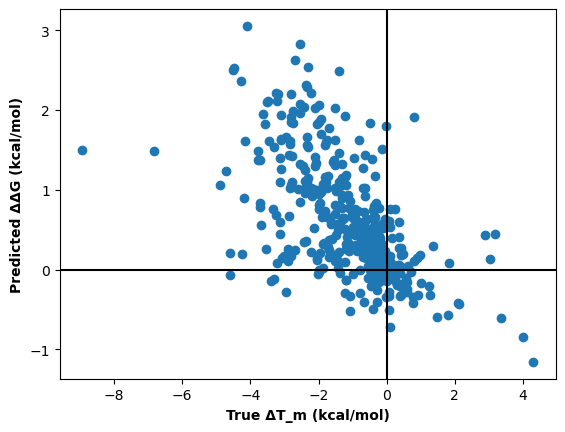

In [111]:
plt.scatter(true, preds)
plt.xlabel('True ΔT_m (kcal/mol)', fontweight='bold')
plt.ylabel('Predicted ΔΔG (kcal/mol)', fontweight='bold')
plt.axhline(0, color='black', linestyle='-')
plt.axvline(0, color='black', linestyle='-')

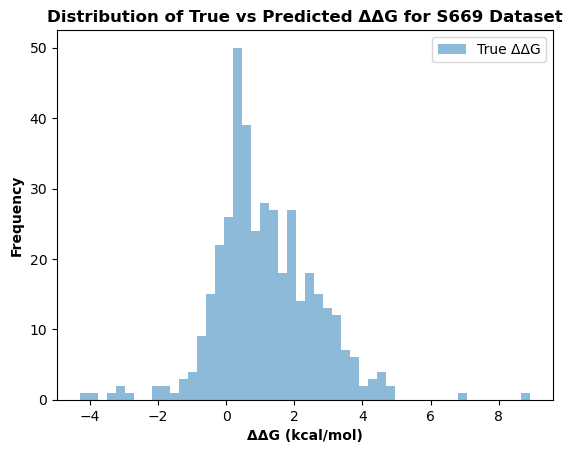

In [99]:
plt.hist(true_labels, bins=50, alpha=0.5, label='True ΔΔG')
# plt.hist(preds, bins=50, alpha=0.5, label='Predicted ΔΔG')
plt.xlabel('ΔΔG (kcal/mol)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of True vs Predicted ΔΔG for S669 Dataset', fontweight='bold')
plt.legend()

## Testing and random

In [1]:
from datasets import Skempi2Dataset
from omegaconf import OmegaConf 

cfg = OmegaConf.load("configs/config.yaml")
cfg = OmegaConf.merge(cfg, OmegaConf.load("configs/local.yaml"))
cfg = OmegaConf.merge(cfg, OmegaConf.from_cli())
dataset = Skempi2Dataset(cfg, 'train')
print(dataset.split)
print(len(dataset.wt_names))

/home/user/miniconda3/envs/mlfold/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


train
273


In [3]:
pdb, mutations = dataset[0]
print(pdb[0].keys())
pdb[0]

dict_keys(['seq_chain_A', 'coords_chain_A', 'seq_chain_B', 'coords_chain_B', 'name', 'num_of_chains', 'seq'])


{'seq_chain_A': 'FPTIPLSRLFDNAMLRAHRLHQLAFDTYQEFEEAYIPKEQKYSFLQNPQTSLCFSESIPTPSNREETQQKSNLELLRISLLLIQSWLEPVQFLRSVFANSLVYGASDSNVYDLLKDLEERIQTLMGRLEGQIFKQTYSKFDTDALLKNYGLLYCFRKDMDKVETFLRIVQCRSVEGSCGF',
 'coords_chain_A': {'N_chain_A': [[73.227, 31.442, 101.41],
   [69.795, 30.848, 101.863],
   [67.332, 30.007, 104.493],
   [65.14, 27.498, 105.75],
   [61.873, 28.357, 106.871],
   [61.383, 28.513, 110.4],
   [59.033, 28.358, 111.781],
   [56.942, 26.174, 111.555],
   [58.076, 24.133, 112.965],
   [58.679, 25.432, 115.453],
   [56.081, 25.973, 116.151],
   [55.078, 23.348, 116.586],
   [56.651, 22.467, 118.751],
   [56.011, 24.242, 120.693],
   [53.321, 23.556, 121.164],
   [53.379, 21.174, 122.395],
   [54.915, 21.778, 124.721],
   [53.11, 23.405, 126.043],
   [51.115, 21.637, 126.469],
   [52.243, 19.823, 128.149],
   [52.932, 21.58, 130.325],
   [50.341, 22.322, 130.881],
   [49.229, 19.879, 131.837],
   [50.813, 19.439, 134.085],
   [50.277, 21.673, 135.701],
   [47.387, 21.401, 136.08

In [8]:
mutations[0]

Mutation(position=7, wildtype='H', mutation='A', ddG=tensor([0.9041]), pdb='1A4Y', chain='B')

In [ ]:
import pickle
import pandas as pd

data  = pd.read_csv("/home/user/Documents/ProteinMPNN/datasets/SKEMPI2_single_point_filtered.csv")
print(data.shape)
with open("/home/user/Documents/ProteinMPNN/dataset-filtering/skempi2_pdb_seqs_splits.pkl", "rb") as f:
    splits = pickle.load(f)

count = 0
for pdb in splits['test']:
    sub_data = data.query('Pdb_origin == @pdb')
    count += len(sub_data)
print(count) 

(4546, 9)
323


Stable: 21.76%
Unstable: 78.24%


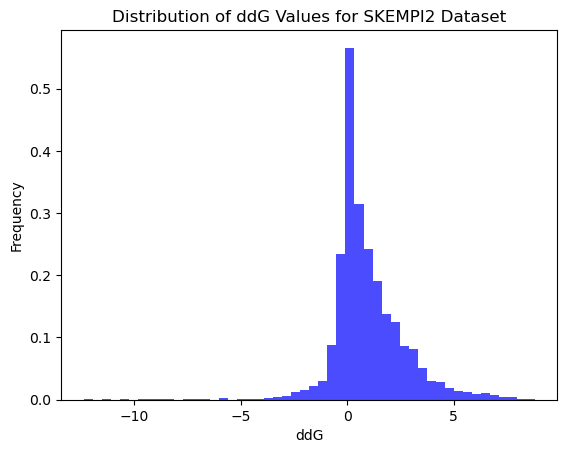

In [144]:
import matplotlib.pyplot as plt

ddG = data['ddG']
stable = data[data['ddG'] < 0]
unstable = data[data['ddG'] >= 0]
print(f"Stable: {stable.shape[0]/len(data)*100:.2f}%")
print(f"Unstable: {unstable.shape[0]/len(data)*100:.2f}%")

plt.hist(ddG, bins=50, alpha=0.7, color='blue', density=True)
plt.xlabel('ddG')
plt.ylabel('Frequency')
plt.title('Distribution of ddG Values for SKEMPI2 Dataset')
plt.show()